# Калибровка моделей PD: сравнение методов с акцентом на сплайн-калибровку

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from IPython.display import display
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from data.generate_data import generate_credit_data, get_oot_split, portfolio_summary
from src.calibrators import get_all_calibrators
from src.metrics import (
    brier_score,
    bootstrap_ci,
    discrimination_metrics,
    fixed_bin_table,
    get_calibration_curve,
    summary_metrics,
)
from src.capital import IRBAssumptions, compare_irb_capital_by_method, calculate_irb_capital
from src.portfolio import (
    MASTER_SCALE_RATINGS,
    assign_master_scale_ratings,
    compare_methods_by_historical_panel,
    compare_methods_by_rating_master_scale,
    historical_portfolio_panel,
    method_portfolio_summary,
    portfolio_average_pd,
    rating_scale_capital,
    summarize_rating_scale,
    validate_common_rating_structure,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]
RANDOM_STATE = 42

print("Библиотеки и проектные модули загружены.")

Библиотеки и проектные модули загружены.


## 1. Постановка исследования и критерии сравнения

В рамках **Basel III / IRB-подхода** калибровка PD нужна не только для того, чтобы прогнозные вероятности совпадали с наблюдаемыми дефолтами по бинам риска, но и для того, чтобы итоговая оценка кредитного риска не искажала **резервы, RWA и требуемый капитал**. Поэтому в работе сравниваются не только графики калибровки, но и прикладной эффект от того, как каждый метод перераспределяет PD по шкале риска.

В исследовании сопоставляются шесть вариантов оценки PD на одной и той же базовой модели: **RF без калибровки**, **логит-калибровка**, **изотоническая регрессия**, **бета-калибровка**, **сплайн-калибровка** и **французский сплайн-калибровка**. Под сплайн-калибровкой понимается **монотонный гладкий сплайн**. Под **французским сплайном** понимается двухшаговая схема по мотивам подхода Banque de France / ICAS: сначала исходные PD калибруются логит-моделью, а затем логит-калиброванные PD дополнительно сглаживаются сплайном.

**Цель исследования** — определить, какой способ калибровки даёт наиболее обоснованное распределение PD по всей шкале риска и как это отражается на прикладном результате: величине **Reserves**, **RWA**, **требуемого капитала при H1 = 8%** и **экономии капитала относительно сырых PD**.

**Критерии сравнения** разделены на две группы:
- **статистические**: Brier Score, Log-Loss, ECE, HL p-value, а также визуальная согласованность PD с фактическими дефолтами по reliability-diagram и по фиксированным бинам `[0.0–0.1], …, [0.9–1.0]`;
- **прикладные**: итоговые **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%**, **экономия капитала относительно сырых PD** и уровень **H1**, если сохранить капитал, достаточный для сырых PD.

Для сопоставимости прикладной части принимаются фиксированные допущения: **EAD = 1 000 000** для каждого наблюдения и **LGD = 40%**. Поэтому различия в итоговом капитале интерпретируются как эффект именно от выбора метода калибровки PD.

## 2. Данные: синтетический кредитный портфель

In [2]:
df = generate_credit_data(n_samples=40000, random_state=RANDOM_STATE)

print(f"Датасет: {df.shape[0]:,} строк | {df.shape[1]} столбцов")
print(f"Общая доля дефолтов: {df['default'].mean():.2%}")
print(f"Средняя истинная PD в синтетике: {df['true_pd'].mean():.2%}\n")

true_pd_stats = df["true_pd"].describe(percentiles=[0.50, 0.90, 0.95, 0.99])[["min", "50%", "90%", "95%", "99%", "max"]]
print("Распределение истинной PD в портфеле:")
print(true_pd_stats.map(lambda x: f"{x:.2%}"))

segment_stats = (
    df.groupby("risk_segment")
      .agg(наблюдений=("default", "count"), доля_дефолтов=("default", "mean"), средняя_true_pd=("true_pd", "mean"))
)
segment_map = {0: "0 = prime", 1: "1 = standard", 2: "2 = subprime", 3: "3 = distressed"}
segment_stats.index = segment_stats.index.map(segment_map)
segment_stats["доля_дефолтов"] = segment_stats["доля_дефолтов"].map("{:.2%}".format)
segment_stats["средняя_true_pd"] = segment_stats["средняя_true_pd"].map("{:.2%}".format)
print("\nРиск-сегменты синтетического портфеля:")
print(segment_stats)

by_year = df.groupby("origination_year")["default"].agg(всего="count", дефолтов="sum", доля="mean")
by_year["доля"] = by_year["доля"].map("{:.2%}".format)
print("\nДефолты по годам выдачи:")
print(by_year)

display(df.drop(columns=["default", "origination_year", "risk_segment", "true_pd"]).describe().round(2))

Датасет: 40,000 строк | 13 столбцов
Общая доля дефолтов: 13.66%
Средняя истинная PD в синтетике: 13.62%

Распределение истинной PD в портфеле:
min     0.23%
50%     1.76%
90%    51.22%
95%    82.49%
99%    95.24%
max    99.58%
Name: true_pd, dtype: str

Риск-сегменты синтетического портфеля:
                наблюдений доля_дефолтов средняя_true_pd
risk_segment                                            
0 = prime            15119         0.69%           0.63%
1 = standard         13601         2.54%           2.60%
2 = subprime          8082        28.97%          29.06%
3 = distressed        3198        83.52%          82.86%

Дефолты по годам выдачи:
                  всего  дефолтов    доля
origination_year                         
2019               5513       739  13.40%
2020               5576       839  15.05%
2021               7219       983  13.62%
2022               7275       964  13.25%
2023               8045      1021  12.69%
2024               6372       916  14.38%


,credit_score,ltv,dti,employment_years,loan_amount,loan_term,num_delinquencies,loan_purpose
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,654.48,0.42,0.30,6.38,221.19,45.94,0.51,1.00
std,117.18,0.23,0.20,4.25,229.40,24.13,0.90,0.88
min,300.00,0.05,0.03,0.00,14.80,12.00,0.00,0.00
25%,578.00,0.23,0.13,3.00,103.78,24.00,0.00,0.00
50%,677.00,0.38,0.24,6.00,156.30,48.00,0.00,1.00
75%,747.00,0.61,0.43,9.30,256.40,60.00,1.00,2.00
max,850.00,0.95,0.87,23.90,9119.70,120.00,8.00,2.00


### Историческая структура портфеля по рейтингам

Здесь портфель не сводится к одной средней PD. Мы восстанавливаем его как `год выдачи × рейтинг`: количество наблюдений, доля рейтинга в портфеле, средняя PD, фактическая доля дефолтов и ожидаемое число дефолтов. Одна агрегированная PD выводится только как контрольный итог.


In [3]:
historical_panel_true = historical_portfolio_panel(df, pd_col="true_pd")
portfolio_avg_true_pd = portfolio_average_pd(df, pd_col="true_pd")

print(f"Агрегированная PD портфеля: {portfolio_avg_true_pd:.2%}")
print("Эта величина нужна только как итог; анализ ниже сохраняет структуру год × рейтинг.")

portfolio_view_cols = [
    "origination_year",
    "rating",
    "n_obs",
    "portfolio_count_share",
    "avg_pd",
    "observed_default_rate",
    "expected_defaults",
    "defaults",
    "calibration_ratio",
]
display(
    historical_panel_true[portfolio_view_cols]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "avg_pd": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)


Агрегированная PD портфеля: 13.62%
Эта величина нужна только как итог; анализ ниже сохраняет структуру год × рейтинг.


,origination_year,rating,n_obs,portfolio_count_share,avg_pd,observed_default_rate,expected_defaults,defaults,calibration_ratio
0,2019,A,2061,37.4%,0.57%,0.44%,11.75,9,0.77
1,2019,B,1864,33.8%,2.37%,2.47%,44.11,46,1.04
2,2019,C,1131,20.5%,28.06%,27.06%,317.31,306,0.96
3,2019,D,457,8.3%,81.80%,82.71%,373.84,378,1.01
4,2020,A,2111,37.9%,0.80%,1.09%,16.79,23,1.37
5,2020,B,1945,34.9%,3.27%,3.29%,63.68,64,1.01
6,2020,C,1077,19.3%,34.02%,35.28%,366.37,380,1.04
7,2020,D,443,7.9%,85.64%,83.97%,379.38,372,0.98
8,2021,A,2691,37.3%,0.57%,0.52%,15.38,14,0.91
9,2021,B,2448,33.9%,2.42%,2.57%,59.33,63,1.06


### Проверка сценариев портфеля: normal vs stress

В проекте есть два режима генерации портфеля. Основной notebook дальше использует `stress`, потому что в нем хорошо заселена верхняя часть PD-шкалы и легче увидеть эффект калибровки на RWA. Но для банковской интерпретации полезно отдельно видеть, что `normal` портфель существует и дает более умеренную дефолтность.

In [4]:
scenario_rows = []
for scenario in ["normal", "stress"]:
    scenario_df = generate_credit_data(n_samples=40_000, random_state=RANDOM_STATE, portfolio=scenario)
    summary = portfolio_summary(scenario_df)
    scenario_rows.append({
        "scenario": scenario,
        "n_obs": summary["n_obs"],
        "default_rate": summary["default_rate"],
        "avg_true_pd": summary["avg_true_pd"],
        "p95_true_pd": summary["p95_true_pd"],
        "max_true_pd": summary["max_true_pd"],
    })

scenario_table = pd.DataFrame(scenario_rows).set_index("scenario")
display(
    scenario_table.style.format({
        "default_rate": "{:.2%}",
        "avg_true_pd": "{:.2%}",
        "p95_true_pd": "{:.2%}",
        "max_true_pd": "{:.2%}",
    })
)

print("Дальше в notebook используется stress-сценарий, чтобы проверять калибровку не только в низких PD.")

,n_obs,default_rate,avg_true_pd,p95_true_pd,max_true_pd
scenario,,,,,
normal,40000,4.06%,4.07%,21.39%,97.31%
stress,40000,13.66%,13.62%,82.49%,99.58%


Дальше в notebook используется stress-сценарий, чтобы проверять калибровку не только в низких PD.


## 3. Экспериментальный протокол и схема выборок

В эксперименте используется **out-of-time схема**, близкая к банковской практике валидации:
- **Train (2019–2021)** — обучение базовой модели;
- **Calibration (2022–2023)** — обучение калибраторов только на сырых score базовой модели;
- **Test OOT (2024)** — финальная оценка качества калибровки и капитального эффекта на будущих данных.

Базовая модель оценивается один раз на train-периоде. Затем её score на calibration-выборке подаются на вход каждому калибратору. Откалиброванные PD применяются только к OOT-выборке 2024 года.

Важно, что **test OOT не используется для настройки параметров калибраторов**. Для финальной сплайн-калибровки используется только монотонный гладкий вариант без подбора по тестовой выборке, чтобы избежать утечки информации из test в модельный выбор.

In [5]:
X_train, X_calib, X_test, y_train, y_calib, y_test = get_oot_split(df)

print("Out-of-Time разбивка:")
print(f"  Train       (2019-2021): {len(X_train):,} строк | дефолты: {y_train.mean():.2%}")
print(f"  Calibration (2022-2023): {len(X_calib):,} строк | дефолты: {y_calib.mean():.2%}")
print(f"  Test OOT    (2024):      {len(X_test):,} строк  | дефолты: {y_test.mean():.2%}")

Out-of-Time разбивка:
  Train       (2019-2021): 18,308 строк | дефолты: 13.99%
  Calibration (2022-2023): 15,320 строк | дефолты: 12.96%
  Test OOT    (2024):      6,372 строк  | дефолты: 14.38%


## 4. Базовая модель и исходное качество некалиброванных PD

In [6]:
base_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
base_model.fit(X_train, y_train)

scores_calib = np.clip(base_model.predict_proba(X_calib)[:, 1], 1e-6, 1 - 1e-6)
scores_test  = np.clip(base_model.predict_proba(X_test)[:, 1], 1e-6, 1 - 1e-6)

print(f"Диапазон скоров RF на OOT: [{scores_test.min():.4f}, {scores_test.max():.4f}]")
print(f"Медиана скоров RF:         {np.median(scores_test):.4f}")
print(f"90 / 95 / 99 перцентили:   {np.quantile(scores_test, [0.90, 0.95, 0.99]).round(4)}")
print(f"Скоры > 0.5:               {(scores_test > 0.5).mean():.1%}")

Диапазон скоров RF на OOT: [0.0068, 0.9660]
Медиана скоров RF:         0.0217
90 / 95 / 99 перцентили:   [0.4997 0.7505 0.9092]
Скоры > 0.5:               10.0%


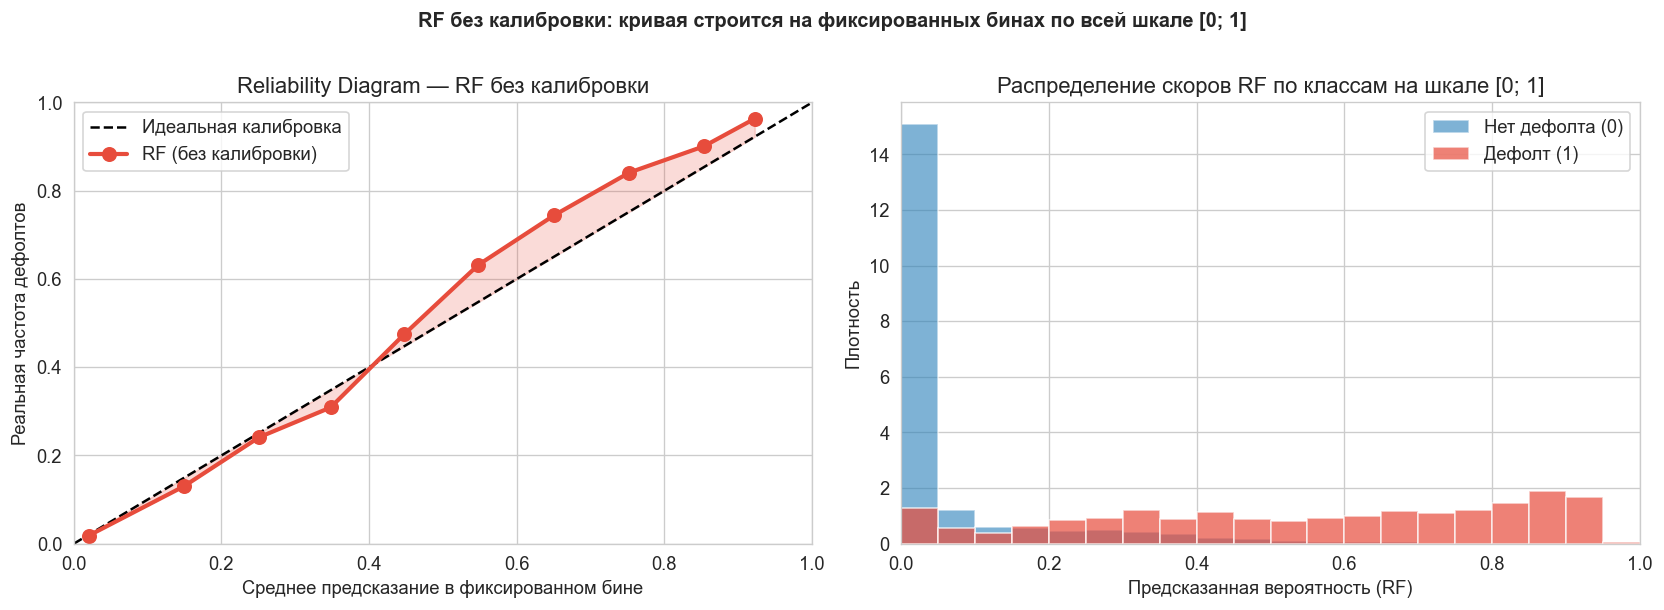

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
mean_pred, frac_pos = get_calibration_curve(y_test.values, scores_test, n_bins=10, strategy="uniform")
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка")
ax.plot(mean_pred, frac_pos, "o-", color=COLORS[0], lw=2.5, ms=8, label="RF (без калибровки)")
ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.2, color=COLORS[0])
ax.set_xlabel("Среднее предсказание в фиксированном бине")
ax.set_ylabel("Реальная частота дефолтов")
ax.set_title("Reliability Diagram — RF без калибровки")
ax.legend()

x_max = max(scores_test.max() * 1.1, 0.35)
y_max = max(frac_pos.max() * 1.15, 0.35)
ax.set_xlim(0, min(x_max, 1.0))
ax.set_ylim(0, min(y_max, 1.0))

ax = axes[1]
ax.hist(scores_test[y_test == 0], bins=np.linspace(0, 1, 21), alpha=0.6, label="Нет дефолта (0)", color=COLORS[1], density=True)
ax.hist(scores_test[y_test == 1], bins=np.linspace(0, 1, 21), alpha=0.7, label="Дефолт (1)", color=COLORS[0], density=True)
ax.set_xlim(0, 1)
ax.set_xlabel("Предсказанная вероятность (RF)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение скоров RF по классам на шкале [0; 1]")
ax.legend()

plt.suptitle(
    "RF без калибровки: кривая строится на фиксированных бинах по всей шкале [0; 1]",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()


### Почему RF без калибровки может быть неидеальной

Хорошее ранжирование не означает хорошую вероятность дефолта. Random Forest может хорошо отделять дефолтных заемщиков от недефолтных, но его сырые `predict_proba` часто требуют посткалибровки:

- **AUC/Gini/KS** отвечают за порядок заемщиков по риску.
- **Brier, Log-Loss, ECE, calibration slope/intercept** отвечают за качество численных PD.
- Если `slope` заметно отличается от 1, модель неверно масштабирует риск.
- Если `intercept` заметно отличается от 0, модель систематически завышает или занижает уровень PD.

Большой пик недефолтных клиентов в низких PD — это нормально: в кредитном портфеле большинство заемщиков не дефолтит, а хорошая модель должна концентрировать таких клиентов в левой части шкалы.

## 5. Сравнение методов калибровки

В итоговом сравнении оставлена **одна базовая сплайн-модель** — **сплайн-калибровка с монотонным ограничением**.  
Причина: для PD-калибровки монотонность является содержательно предпочтительной, поскольку более высокий исходный риск не должен переводиться в более низкую итоговую PD.

Дополнительно вводится **французский сплайн-калибровка** — двухшаговый метод, в котором:
1. исходные PD сначала калибруются **логит-моделью**;
2. затем полученные логит-калиброванные PD дополнительно сглаживаются **монотонным сплайном**.

Таким образом, в ноутбуке сопоставляются простые параметрические, непараметрические и гибридные методы калибровки PD.

In [8]:
calibrators = get_all_calibrators()
calibrated_probs = {}

for name, cal in calibrators.items():
    cal.fit(scores_calib, y_calib.values)
    calibrated_probs[name] = np.clip(cal.predict(scores_test), 1e-6, 1 - 1e-6)
    print(f"{name}: обучен.")

print("\nВсе калибраторы обучены только на calibration-выборке.")

Логит-калибровка: обучен.
Изотоническая регрессия: обучен.
Бета-калибровка: обучен.
Монотонный сплайн: обучен.
Французский сплайн: обучен.

Все калибраторы обучены только на calibration-выборке.


Сравнение монотонного и французского сплайна:
Средняя абсолютная разница: 0.005950
Максимальная абсолютная разница: 0.021229


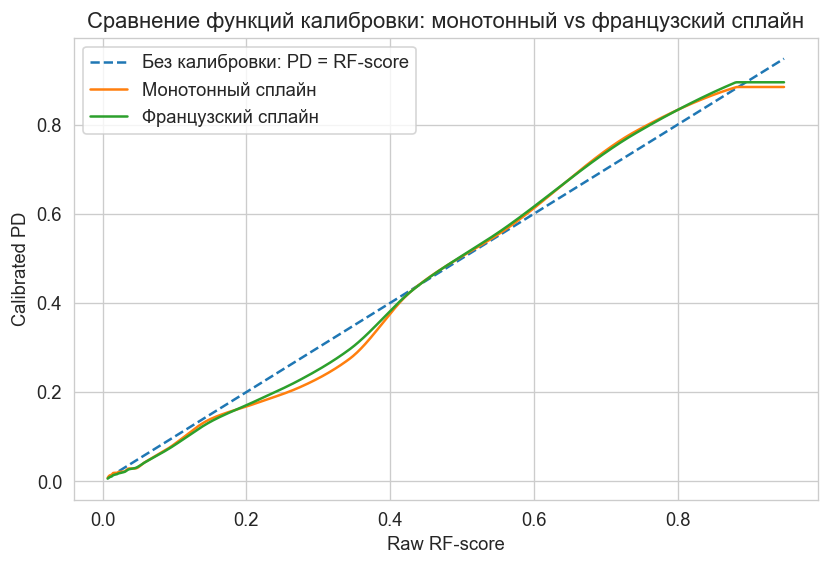

In [9]:
# Проверка различий между монотонным и французским сплайном

score_grid = np.linspace(
    max(1e-4, float(np.quantile(scores_calib, 0.001))),
    min(0.9999, float(np.quantile(scores_calib, 0.999))),
    500
)

mono = calibrators["Монотонный сплайн"]
french = calibrators["Французский сплайн"]

mono_pd = mono.predict(score_grid)
french_pd = french.predict(score_grid)

diff = np.abs(mono_pd - french_pd)

print("Сравнение монотонного и французского сплайна:")
print(f"Средняя абсолютная разница: {diff.mean():.6f}")
print(f"Максимальная абсолютная разница: {diff.max():.6f}")

plt.figure(figsize=(8, 5))

plt.plot(
    score_grid,
    score_grid,
    "--",
    label="Без калибровки: PD = RF-score"
)

plt.plot(
    score_grid,
    mono_pd,
    label="Монотонный сплайн"
)

plt.plot(
    score_grid,
    french_pd,
    label="Французский сплайн"
)

plt.xlabel("Raw RF-score")
plt.ylabel("Calibrated PD")
plt.title("Сравнение функций калибровки: монотонный vs французский сплайн")
plt.legend()
plt.grid(True)
plt.show()

Сравнение функций калибровки показывает, что монотонный и французский сплайн дают близкие преобразования исходного RF-score в откалиброванную PD. Это объясняется тем, что французский сплайн в текущей реализации сначала применяет логит-калибровку, а затем использует тот же механизм монотонного сплайна. Поскольку логит-калибровка в основном является монотонным преобразованием score и почти не меняет порядок наблюдений, последующее биннирование приводит к близкой итоговой кривой.

Следовательно, близкие значения Brier Score, Log-Loss, ECE и RWA для двух сплайн-методов не являются ошибкой. Они отражают то, что французский сплайн в данной реализации является скорее двухшаговой модификацией обычного монотонного сплайна, а не принципиально отдельным методом.

### Интерпретация критериев выбора метода калибровки

Один метод редко оказывается лучшим одновременно по всем критериям. Поэтому выбор метода калибровки зависит от цели анализа. Если задача состоит в минимизации ошибки вероятностного прогноза, нужно смотреть Brier Score и Log-Loss. Если важна согласованность PD с фактической частотой дефолтов по группам риска, важнее ECE, reliability diagrams и backtesting expected defaults. Если требуется простая и объяснимая модель, логит- и beta-калибровка удобнее как базовые benchmark-методы. Если нужна гладкая PD-кривая для рейтинговой шкалы, полезен монотонный сплайн.

При этом результаты OOT-проверки показывают, что лучший метод по отдельной статистической метрике не обязательно лучше по агрегированному числу дефолтов или по капитальному эффекту. В данном эксперименте калиброванные методы снизили средний уровень PD относительно RF, поэтому их экономия капитала должна интерпретироваться осторожно.

In [10]:
print("Metrics and backtesting are calculated below. Final selection table follows later.")

Metrics and backtesting are calculated below. Final selection table follows later.


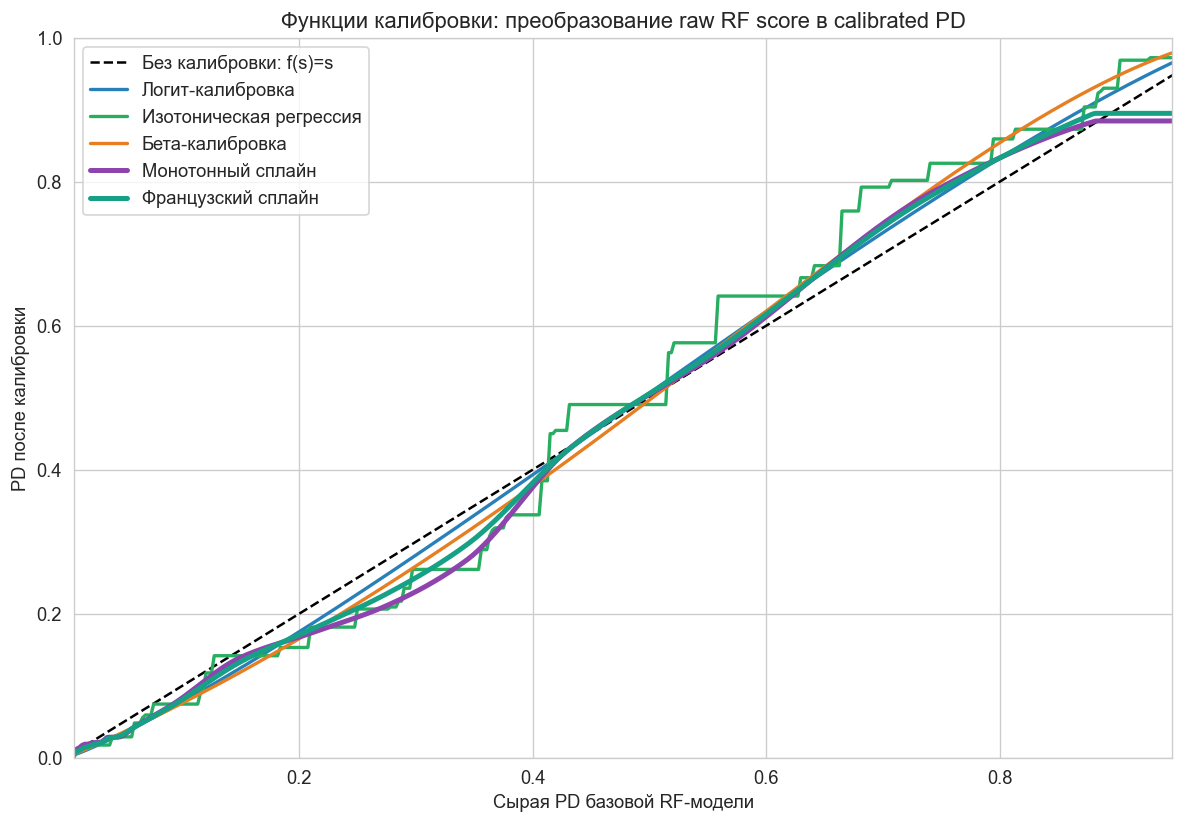

Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.


In [11]:
score_grid = np.linspace(
    max(1e-4, float(np.quantile(scores_calib, 0.001))),
    min(0.9999, float(np.quantile(scores_calib, 0.999))),
    400,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(score_grid, score_grid, "k--", lw=1.5, label="Без калибровки: f(s)=s")

for (name, cal), color in zip(calibrators.items(), COLORS[1:]):
    calibrated_grid = cal.predict(score_grid)
    lw = 3.0 if "сплайн" in name.lower() else 2.0
    ax.plot(score_grid, calibrated_grid, color=color, lw=lw, label=name)

ax.set_xlabel("Сырая PD базовой RF-модели")
ax.set_ylabel("PD после калибровки")
ax.set_title("Функции калибровки: преобразование raw RF score в calibrated PD")
ax.set_xlim(score_grid.min(), score_grid.max())
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Диапазон графика ограничен 0.1% и 99.9% перцентилями calibration-скоров, чтобы редкие экстремумы не сжимали основную область.")

In [12]:
parameter_rows = []
for name, cal in calibrators.items():
    row = {"Метод": name}

    if hasattr(cal, "_model") and hasattr(cal._model, "coef_"):
        row["Параметры"] = (
            f"a={float(cal._model.coef_[0][0]):.4f}, "
            f"b={float(cal._model.intercept_[0]):.4f}"
        )
    elif hasattr(cal, "a_"):
        row["Параметры"] = (
            f"a={cal.a_:.4f}, b={cal.b_:.4f}, c={cal.c_:.4f}, "
            f"success={cal.success_}"
        )
    elif hasattr(cal, "bin_stats_") and cal.bin_stats_ is not None:
        row["Параметры"] = f"число бинов={len(cal.bin_stats_)}"
    elif hasattr(cal, "spline_stage"):
        row["Параметры"] = f"logit + spline, число бинов={len(cal.spline_stage.bin_stats_)}"
    else:
        row["Параметры"] = "непараметрический метод"

    parameter_rows.append(row)

display(pd.DataFrame(parameter_rows).set_index("Метод"))

,Параметры
Метод,
Логит-калибровка,"a=1.1379, b=0.0265"
Изотоническая регрессия,непараметрический метод
Бета-калибровка,"a=1.0278, b=-1.4151, c=-0.2811, success=True"
Монотонный сплайн,число бинов=30
Французский сплайн,число бинов=30


## 6. Результаты на OOT: метрики и визуальная диагностика

**Важно для интерпретации графиков.**  
Кривые калибровки в этой версии строятся на **фиксированных бинах по всей шкале [0; 1]**.  
Это исправляет прежнюю проблему, когда при квантильной разбивке последняя точка на оси X показывала лишь **среднее значение верхнего дециля**, поэтому визуально казалось, что все методы обрываются около `0.15`, хотя фактические максимумы PD были выше.

In [13]:
results = [summary_metrics(y_test.values, scores_test, name="RF без калибровки")]
for name, probs in calibrated_probs.items():
    results.append(summary_metrics(y_test.values, probs, name=name))

df_results = pd.DataFrame(results).set_index("method")

print("Метрики на OOT-выборке, 2024 год:")
print("  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше")
print("  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий")
print("  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке")

df_results_ru = df_results.rename(columns={
    "brier_score": "Brier Score",
    "log_loss": "Log-Loss",
    "ece_uniform": "ECE (фикс. бины)",
    "ece_quantile": "ECE (квант. бины)",
    "hl_chi2": "HL chi2",
    "hl_p_value": "HL p-value",
    "cal_slope": "Cal. slope",
    "cal_intercept": "Cal. intercept",
})

display(
    df_results_ru.round({
        "Brier Score": 5,
        "Log-Loss": 5,
        "ECE (фикс. бины)": 5,
        "ECE (квант. бины)": 5,
        "HL chi2": 3,
        "HL p-value": 4,
        "Cal. slope": 4,
        "Cal. intercept": 4,
    })
)

disc_rows = []
all_preds = {"RF без калибровки": scores_test, **calibrated_probs}
for name, probs in all_preds.items():
    disc_rows.append(discrimination_metrics(y_test.values, probs, name=name))

df_disc = pd.DataFrame(disc_rows).set_index("method")
print("\nМетрики ранжирования (AUC / Gini / KS):")
print(df_disc.to_string())
print("\nКомментарий: строго монотонные преобразования обычно сохраняют ранжирование;")
print("изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.")

prob_range_rows = []
for name, probs in all_preds.items():
    prob_range_rows.append({
        "method": name,
        "min_pd": np.min(probs),
        "p95_pd": np.quantile(probs, 0.95),
        "max_pd": np.max(probs),
    })

df_prob_ranges = pd.DataFrame(prob_range_rows).set_index("method")
df_prob_ranges_ru = df_prob_ranges.rename(columns={
    "min_pd": "Мин. PD",
    "p95_pd": "95-й перцентиль PD",
    "max_pd": "Макс. PD",
})
print("\nФактический диапазон PD на OOT:")
display(df_prob_ranges_ru.round(4))

Метрики на OOT-выборке, 2024 год:
  Brier Score, Log-Loss, ECE  — чем меньше, тем лучше
  HL p-value                  — чем больше, тем лучше, но при большом n тест часто слишком строгий
  Slope ~ 1, Intercept ~ 0    — ближе к идеальной калибровке


,Brier Score,Log-Loss,ece,ECE (фикс. бины),ECE (квант. бины),HL chi2,HL p-value,Cal. slope,Cal. intercept
method,,,,,,,,,
RF без калибровки,0.06134,0.20908,0.01258,0.01279,0.01258,23.875,0.0024,1.1082,0.1525
Логит-калибровка,0.06105,0.20884,0.00963,0.01152,0.00963,29.075,0.0003,0.9733,0.1247
Изотоническая регрессия,0.06094,0.20955,0.01015,0.00994,0.01015,24.542,0.0019,0.9610,0.1188
Бета-калибровка,0.06103,0.20837,0.00938,0.01236,0.00938,19.364,0.0130,0.9785,0.1309
Монотонный сплайн,0.06126,0.20920,0.01298,0.01006,0.01298,20.727,0.0079,1.0764,0.2464
Французский сплайн,0.06114,0.20870,0.01142,0.01203,0.01142,19.184,0.0139,1.0362,0.2037



Метрики ранжирования (AUC / Gini / KS):
                         auc_roc    gini  ks_stat
method                                           
RF без калибровки         0.9316  0.8633   0.7380
Логит-калибровка          0.9316  0.8633   0.7380
Изотоническая регрессия   0.9313  0.8625   0.7317
Бета-калибровка           0.9316  0.8633   0.7380
Монотонный сплайн         0.9315  0.8631   0.7380
Французский сплайн        0.9316  0.8633   0.7380

Комментарий: строго монотонные преобразования обычно сохраняют ранжирование;
изотоническая и сплайн-калибровка могут немного менять AUC/Gini из-за ties или сглаживания.

Фактический диапазон PD на OOT:


,Мин. PD,95-й перцентиль PD,Макс. PD
method,,,
RF без калибровки,0.0068,0.7505,0.9660
Логит-калибровка,0.0035,0.7823,0.9788
Изотоническая регрессия,0.0000,0.8256,1.0000
Бета-калибровка,0.0045,0.8003,0.9887
Монотонный сплайн,0.0074,0.7928,0.8844
Французский сплайн,0.0057,0.7891,0.8949


### Backtesting методов на исторической структуре OOT-портфеля

После калибровки сравниваем методы не только одной строкой метрик, но и на уровне `2024 × рейтинг`. Это отвечает на вопрос, какой метод лучше сохраняет риск-профиль портфеля по разным рейтингам.


In [14]:
df_test = df.loc[y_test.index].copy()
oot_predictions = {"RF без калибровки": scores_test, **calibrated_probs}

method_summary = method_portfolio_summary(df_test, oot_predictions)
rating_method_panel = compare_methods_by_historical_panel(df_test, oot_predictions)

print("Агрегированный итог по OOT-портфелю, 2024:")
display(
    method_summary[[
        "avg_pd",
        "defaults",
        "expected_defaults",
        "default_gap",
        "calibration_ratio",
    ]]
    .style.format({
        "avg_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "default_gap": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)

print("Детализация по рейтингу на OOT-периоде:")
rating_view_cols = [
    "method",
    "origination_year",
    "rating",
    "n_obs",
    "portfolio_count_share",
    "avg_pd",
    "observed_default_rate",
    "expected_defaults",
    "defaults",
    "calibration_ratio",
]
display(
    rating_method_panel[rating_view_cols]
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "avg_pd": "{:.2%}",
        "observed_default_rate": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "calibration_ratio": "{:.2f}",
    })
)


Агрегированный итог по OOT-портфелю, 2024:


,avg_pd,defaults,expected_defaults,default_gap,calibration_ratio
method,,,,,
RF без калибровки,14.06%,916.000000,895.84,20.16,1.02
Логит-калибровка,13.47%,916.000000,858.14,57.86,1.07
Изотоническая регрессия,13.43%,916.000000,855.81,60.19,1.07
Бета-калибровка,13.46%,916.000000,857.73,58.27,1.07
Монотонный сплайн,13.38%,916.000000,852.58,63.42,1.07
Французский сплайн,13.36%,916.000000,851.41,64.59,1.08


Детализация по рейтингу на OOT-периоде:


,method,origination_year,rating,n_obs,portfolio_count_share,avg_pd,observed_default_rate,expected_defaults,defaults,calibration_ratio
0,RF без калибровки,2024,A,2379,37.3%,0.93%,1.01%,22.24,24,1.08
1,RF без калибровки,2024,B,2159,33.9%,3.50%,2.36%,75.64,51,0.67
2,RF без калибровки,2024,C,1322,20.7%,31.01%,30.33%,409.93,401,0.98
3,RF без калибровки,2024,D,512,8.0%,75.79%,85.94%,388.03,440,1.13
4,Логит-калибровка,2024,A,2379,37.3%,0.51%,1.01%,12.12,24,1.98
5,Логит-калибровка,2024,B,2159,33.9%,2.42%,2.36%,52.17,51,0.98
6,Логит-калибровка,2024,C,1322,20.7%,29.73%,30.33%,393.09,401,1.02
7,Логит-калибровка,2024,D,512,8.0%,78.27%,85.94%,400.77,440,1.10
8,Изотоническая регрессия,2024,A,2379,37.3%,0.62%,1.01%,14.81,24,1.62
9,Изотоническая регрессия,2024,B,2159,33.9%,2.52%,2.36%,54.34,51,0.94


### Как выбирать метод калибровки

Один метод редко является лучшим по всем критериям одновременно. Поэтому ниже метод выбирается не только по статистической метрике, но и по практической роли в банковской модели.

In [15]:
selection_table = pd.DataFrame([
    {
        "Сценарий выбора": "Минимизировать Brier / Log-Loss",
        "Что смотреть": "Brier Score, Log-Loss",
        "Типичный кандидат": df_results["brier_score"].idxmin(),
        "Комментарий": "Лучше для чистого качества вероятностного прогноза.",
    },
    {
        "Сценарий выбора": "Минимизировать ошибку калибровки",
        "Что смотреть": "ECE на квантильных и фиксированных бинах",
        "Типичный кандидат": df_results["ece_quantile"].idxmin(),
        "Комментарий": "Полезно для reliability diagrams и backtesting PD.",
    },
    {
        "Сценарий выбора": "Сохранить простоту и интерпретируемость",
        "Что смотреть": "Стабильность, slope/intercept, governance",
        "Типичный кандидат": "Логит-калибровка / Бета-калибровка",
        "Комментарий": "Хорошие базовые benchmark-методы.",
    },
    {
        "Сценарий выбора": "Получить гладкую PD-кривую",
        "Что смотреть": "ECE, графики, отсутствие ступеней",
        "Типичный кандидат": "Монотонный сплайн / Французский сплайн",
        "Комментарий": "Удобно для банковской master scale и презентации калибровочной функции.",
    },
    {
        "Сценарий выбора": "Оценить capital impact",
        "Что смотреть": "RWA, required capital, H1 if keep raw capital",
        "Типичный кандидат": "Определяется отдельно в RWA-блоке",
        "Комментарий": "Лучший по Brier метод не обязан давать минимальный капитал.",
    },
])

display(selection_table)

,Сценарий выбора,Что смотреть,Типичный кандидат,Комментарий
0,Минимизировать Brier / Log-Loss,"Brier Score, Log-Loss",Изотоническая регрессия,Лучше для чистого качества вероятностного прог...
1,Минимизировать ошибку калибровки,ECE на квантильных и фиксированных бинах,Бета-калибровка,Полезно для reliability diagrams и backtesting...
2,Сохранить простоту и интерпретируемость,"Стабильность, slope/intercept, governance",Логит-калибровка / Бета-калибровка,Хорошие базовые benchmark-методы.
3,Получить гладкую PD-кривую,"ECE, графики, отсутствие ступеней",Монотонный сплайн / Французский сплайн,Удобно для банковской master scale и презентац...
4,Оценить capital impact,"RWA, required capital, H1 if keep raw capital",Определяется отдельно в RWA-блоке,Лучший по Brier метод не обязан давать минимал...


### Эффект калибровки на резервы, RWA и требуемый капитал

После статистического сравнения каждая версия PD переводится в прикладные показатели: **Reserves**, **имплицитный RWA**, **требуемый капитал при H1 = 8%** и **Capital_true**. Это позволяет оценить не только качество калибровки как статистической процедуры, но и её влияние на капитальную нагрузку портфеля.

Для чистоты сравнения используется фиксированное допущение **EAD = 1 000 000** на каждое наблюдение и **LGD = 40%**. Поэтому различия между методами интерпретируются как эффект именно от калиброванной **PD**, а не от разного размера экспозиции.

Дополнительно рассчитывается, сколько капитала можно высвободить относительно **сырых PD** при целевом нормативе **H1 = 8%**, а также каким станет фактический **H1**, если сохранить капитал, достаточный для некалиброванной базовой модели.

### Rating Master Scale: калибровка PD по рейтинговой шкале

В этом блоке портфель собирается не напрямую по индивидуальным PD, а по рейтинговой шкале `A1 ... E`. Каждый рейтинг получает свою PD. Затем PD по рейтингам сдвигаются на logit-шкале так, чтобы средневзвешенная PD портфеля совпала с целевой CT. Для первого приближения CT берется из calibration-периода, а EAD каждого актива равен `1_000_000`.


In [16]:
TARGET_CT = float(y_calib.mean())
ASSET_EAD = 1_000_000.0

df_calib_master = df.loc[y_calib.index].copy()
df_test_master = df.loc[y_test.index].copy()
df_calib_master["master_rating"] = assign_master_scale_ratings(
    scores_calib, reference_scores=scores_calib
)
df_test_master["master_rating"] = assign_master_scale_ratings(
    scores_test, reference_scores=scores_calib
)

excel_logit = LogisticRegression(solver="lbfgs", max_iter=1000, C=1e12)
excel_logit.fit(scores_calib.reshape(-1, 1), y_calib.values)
excel_logit_pd = np.clip(
    excel_logit.predict_proba(scores_test.reshape(-1, 1))[:, 1],
    1e-6,
    1 - 1e-6,
)

rating_scale_predictions = {
    "Excel logit(score)": excel_logit_pd,
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

master_scale_panel = compare_methods_by_rating_master_scale(
    df_test_master,
    rating_scale_predictions,
    score_values=scores_test,
    target_pd=TARGET_CT,
    default_asset_ead=ASSET_EAD,
)
master_scale_summary = summarize_rating_scale(master_scale_panel, method_col="method")


master_scale_capital = rating_scale_capital(
    master_scale_panel,
    assumptions=IRBAssumptions(lgd=0.40, maturity_years=2.5, ead=ASSET_EAD),
    method_col="method",
)

rating_pd_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="pd_rating")
    .loc[list(MASTER_SCALE_RATINGS)]
)

display(
    rating_pd_matrix.style.format("{:.2%}")
)

# Critical methodology check: every method must use the same borrowers
# in every rating bucket. Calibration methods may change only PD, not
# the portfolio composition.
master_scale_structure_check = validate_common_rating_structure(master_scale_panel)

print(f"Target CT по calibration-периоду: {TARGET_CT:.2%}")
print(f"OOT default rate:                 {y_test.mean():.2%}")
print(f"EAD на один актив:                {ASSET_EAD:,.0f}")

display(
    master_scale_summary[[
        "n_assets",
        "target_weighted_pd",
        "defaults",
        "expected_defaults",
        "pd_min",
        "pd_max",
    ]]
    .style.format({
        "target_weighted_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
        "pd_min": "{:.2%}",
        "pd_max": "{:.2%}",
    })
)

master_scale_method = "Excel logit(score)"
master_scale_view_cols = [
    "rating",
    "avg_score",
    "n_assets",
    "portfolio_count_share",
    "observed_default_rate",
    "pd_before_target",
    "pd_rating",
    "one_minus_pd",
    "expected_defaults",
]
display(
    master_scale_panel.loc[
        master_scale_panel["method"] == master_scale_method,
        master_scale_view_cols,
    ]
    .style.format({
        "avg_score": "{:.4f}",
        "portfolio_count_share": "{:.1%}",
        "observed_default_rate": "{:.2%}",
        "pd_before_target": "{:.2%}",
        "pd_rating": "{:.2%}",
        "one_minus_pd": "{:.2%}",
        "expected_defaults": "{:.2f}",
    })
)


method,Excel logit(score),RF без калибровки,Бета-калибровка,Изотоническая регрессия,Логит-калибровка,Монотонный сплайн,Французский сплайн
rating,,,,,,,
A1,2.00%,0.63%,0.45%,0.17%,0.36%,0.69%,0.54%
A2,2.01%,0.67%,0.48%,0.38%,0.39%,0.83%,0.62%
A3,2.02%,0.73%,0.53%,0.63%,0.43%,1.06%,0.74%
B1,2.04%,0.83%,0.60%,0.72%,0.49%,1.20%,0.85%
B2,2.06%,0.98%,0.71%,0.84%,0.59%,1.29%,0.95%
B3,2.12%,1.30%,0.96%,1.19%,0.82%,1.67%,1.27%
C1,2.22%,1.79%,1.33%,1.35%,1.18%,1.85%,1.56%
C2,2.37%,2.54%,1.92%,1.62%,1.76%,2.13%,1.99%
C3,2.71%,4.02%,3.11%,2.79%,2.99%,3.04%,3.05%


Target CT по calibration-периоду: 12.96%
OOT default rate:                 14.38%
EAD на один актив:                1,000,000


,n_assets,target_weighted_pd,defaults,expected_defaults,pd_min,pd_max
method,,,,,,
Excel logit(score),6372,12.96%,916.000000,825.61,2.00%,87.03%
RF без калибровки,6372,12.96%,916.000000,825.61,0.63%,75.52%
Бета-калибровка,6372,12.96%,916.000000,825.61,0.45%,81.57%
Изотоническая регрессия,6372,12.96%,916.000000,825.61,0.17%,82.19%
Логит-калибровка,6372,12.96%,916.000000,825.61,0.36%,79.88%
Монотонный сплайн,6372,12.96%,916.000000,825.61,0.69%,78.91%
Французский сплайн,6372,12.96%,916.000000,825.61,0.54%,79.24%


,rating,avg_score,n_assets,portfolio_count_share,observed_default_rate,pd_before_target,pd_rating,one_minus_pd,expected_defaults
0,A1,0.0074,473,7.4%,0.85%,2.17%,2.00%,98.00%,9.46
1,A2,0.0079,484,7.6%,1.03%,2.18%,2.01%,97.99%,9.72
2,A3,0.0086,514,8.1%,0.39%,2.19%,2.02%,97.98%,10.37
3,B1,0.0098,468,7.3%,0.64%,2.21%,2.04%,97.96%,9.53
4,B2,0.0116,453,7.1%,1.55%,2.24%,2.06%,97.94%,9.35
5,B3,0.0153,516,8.1%,1.94%,2.30%,2.12%,97.88%,10.96
6,C1,0.0211,462,7.3%,0.65%,2.41%,2.22%,97.78%,10.25
7,C2,0.0298,507,8.0%,2.76%,2.57%,2.37%,97.63%,12.02
8,C3,0.0471,465,7.3%,3.66%,2.93%,2.71%,97.29%,12.58
9,D1,0.1160,491,7.7%,11.20%,5.08%,4.69%,95.31%,23.04


1. A1...E — это новая master scale по RF-score, а не старые A/B/C/D.
2. Excel logit(score) — технический benchmark для сопоставления с Excel, а не основной метод калибровки.
3. Все expected_defaults одинаковые, потому что PD принудительно сдвигаются к CT = 12.96%.
4. Этот блок сравнивает форму рейтинговой шкалы, а не точность попадания в OOT default rate.

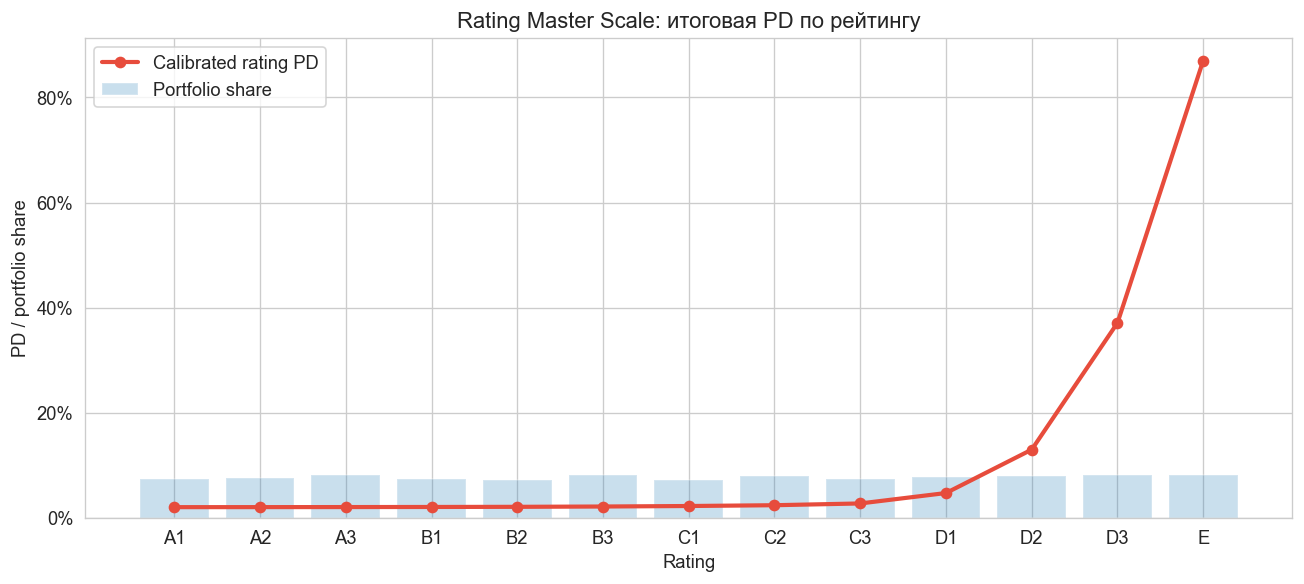

,total_ead,total_expected_loss,total_rwa,total_required_capital,rwa_rate_to_ead
method,,,,,
Excel logit(score),"6,372,000,000","330,245,953","7,557,034,339","604,562,747",118.60%
RF без калибровки,"6,372,000,000","330,245,953","7,428,854,131","594,308,330",116.59%
Бета-калибровка,"6,372,000,000","330,245,953","6,830,349,243","546,427,939",107.19%
Изотоническая регрессия,"6,372,000,000","330,245,953","6,755,990,409","540,479,233",106.03%
Логит-калибровка,"6,372,000,000","330,245,953","6,679,291,234","534,343,299",104.82%
Монотонный сплайн,"6,372,000,000","330,245,953","7,462,052,352","596,964,188",117.11%
Французский сплайн,"6,372,000,000","330,245,953","7,161,165,176","572,893,214",112.38%


In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_scale = master_scale_panel[master_scale_panel["method"] == master_scale_method].copy()
ax.plot(
    plot_scale["rating"],
    plot_scale["pd_rating"],
    marker="o",
    linewidth=2.5,
    color=COLORS[0],
    label="Calibrated rating PD",
)
ax.bar(
    plot_scale["rating"],
    plot_scale["portfolio_count_share"],
    alpha=0.25,
    color=COLORS[1],
    label="Portfolio share",
)
ax.set_xlabel("Rating")
ax.set_ylabel("PD / portfolio share")
ax.set_title("Rating Master Scale: итоговая PD по рейтингу")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

display(
    master_scale_capital[[
        "total_ead",
        "total_expected_loss",
        "total_rwa",
        "total_required_capital",
        "rwa_rate_to_ead",
    ]]
    .style.format({
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "rwa_rate_to_ead": "{:.2%}",
    })
)


### Контроль честности сравнения методов

Для корректного сравнения все методы должны работать на одной и той же структуре портфеля. Поэтому количество активов, EAD, фактические дефолты и доля портфеля в каждом рейтинге должны совпадать для всех методов. Различаться должны только калиброванные PD и рассчитанные от них EL/RWA.


In [18]:
display(
    master_scale_structure_check
    .style.format({"max_abs_difference": "{:.12f}"})
)

fixed_structure_fields = [
    "n_assets",
    "total_ead",
    "defaults",
    "observed_default_rate",
    "portfolio_count_share",
    "portfolio_ead_share",
]
print("Проверка пройдена: рейтинговая структура портфеля одинакова для всех методов.")
print("Фиксированные поля:", ", ".join(fixed_structure_fields))
print("Методы калибровки меняют только PD и производные от PD показатели: expected loss, RWA, capital.")


,field,is_common,max_abs_difference
0,n_assets,True,0.000000000000
1,total_ead,True,0.000000000000
2,defaults,True,0.000000000000
3,observed_default_rate,True,0.000000000000
4,portfolio_count_share,True,0.000000000000
5,portfolio_ead_share,True,0.000000000000


Проверка пройдена: рейтинговая структура портфеля одинакова для всех методов.
Фиксированные поля: n_assets, total_ead, defaults, observed_default_rate, portfolio_count_share, portfolio_ead_share
Методы калибровки меняют только PD и производные от PD показатели: expected loss, RWA, capital.


### Сравнение рейтинговых PD по всем методам

Теперь смотрим не один выбранный метод, а всю матрицу `rating × method`. Это показывает, какую PD каждый метод присваивает одному и тому же рейтингу после приведения к целевой CT. Распределение портфеля по рейтингам остается общим, потому что рейтинги назначены по базовому score.


method,Excel logit(score),RF без калибровки,Бета-калибровка,Изотоническая регрессия,Логит-калибровка,Монотонный сплайн,Французский сплайн
rating,,,,,,,
A1,2.00%,0.63%,0.45%,0.17%,0.36%,0.69%,0.54%
A2,2.01%,0.67%,0.48%,0.38%,0.39%,0.83%,0.62%
A3,2.02%,0.73%,0.53%,0.63%,0.43%,1.06%,0.74%
B1,2.04%,0.83%,0.60%,0.72%,0.49%,1.20%,0.85%
B2,2.06%,0.98%,0.71%,0.84%,0.59%,1.29%,0.95%
B3,2.12%,1.30%,0.96%,1.19%,0.82%,1.67%,1.27%
C1,2.22%,1.79%,1.33%,1.35%,1.18%,1.85%,1.56%
C2,2.37%,2.54%,1.92%,1.62%,1.76%,2.13%,1.99%
C3,2.71%,4.02%,3.11%,2.79%,2.99%,3.04%,3.05%


,n_assets,portfolio_count_share,observed_default_rate
rating,,,
A1,473,7.4%,0.85%
A2,484,7.6%,1.03%
A3,514,8.1%,0.39%
B1,468,7.3%,0.64%
B2,453,7.1%,1.55%
B3,516,8.1%,1.94%
C1,462,7.3%,0.65%
C2,507,8.0%,2.76%
C3,465,7.3%,3.66%


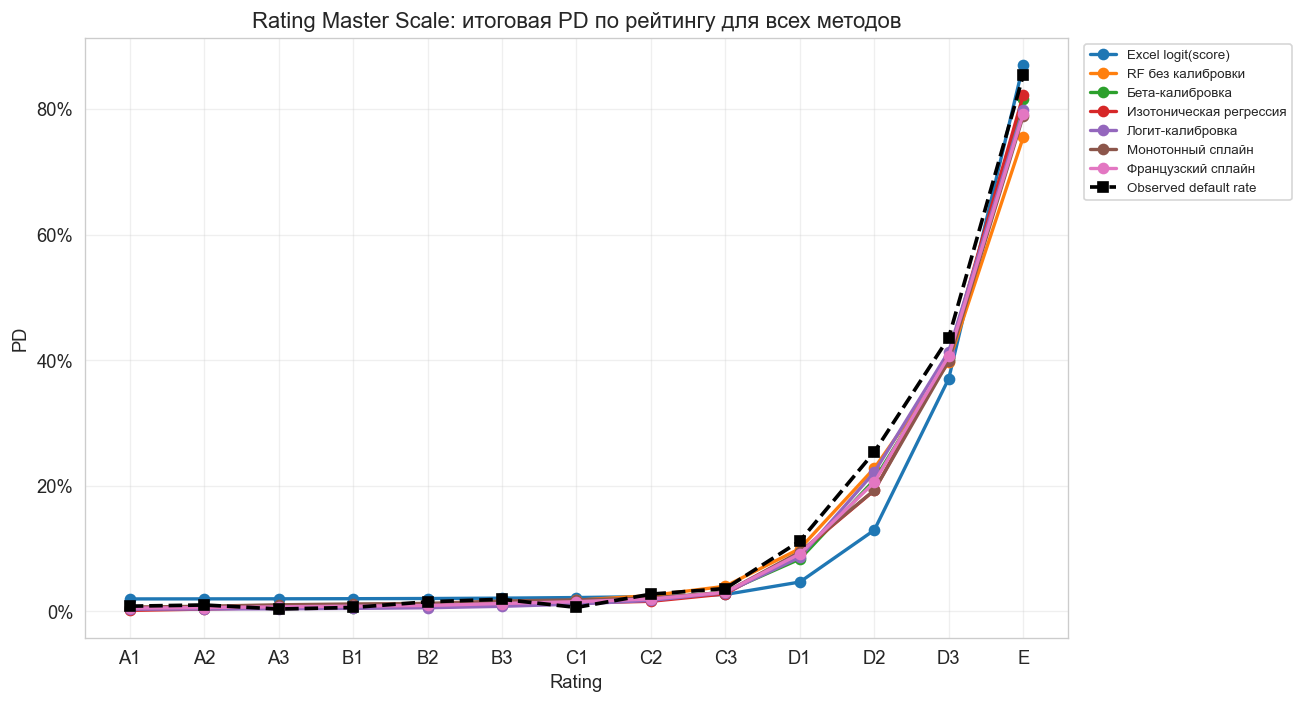

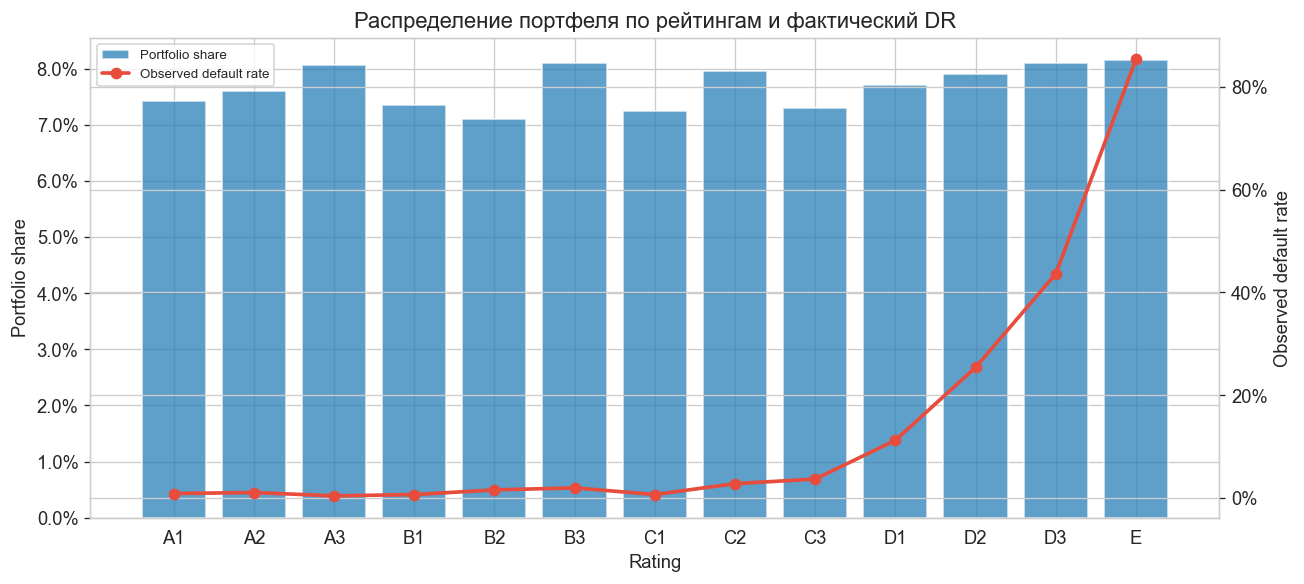

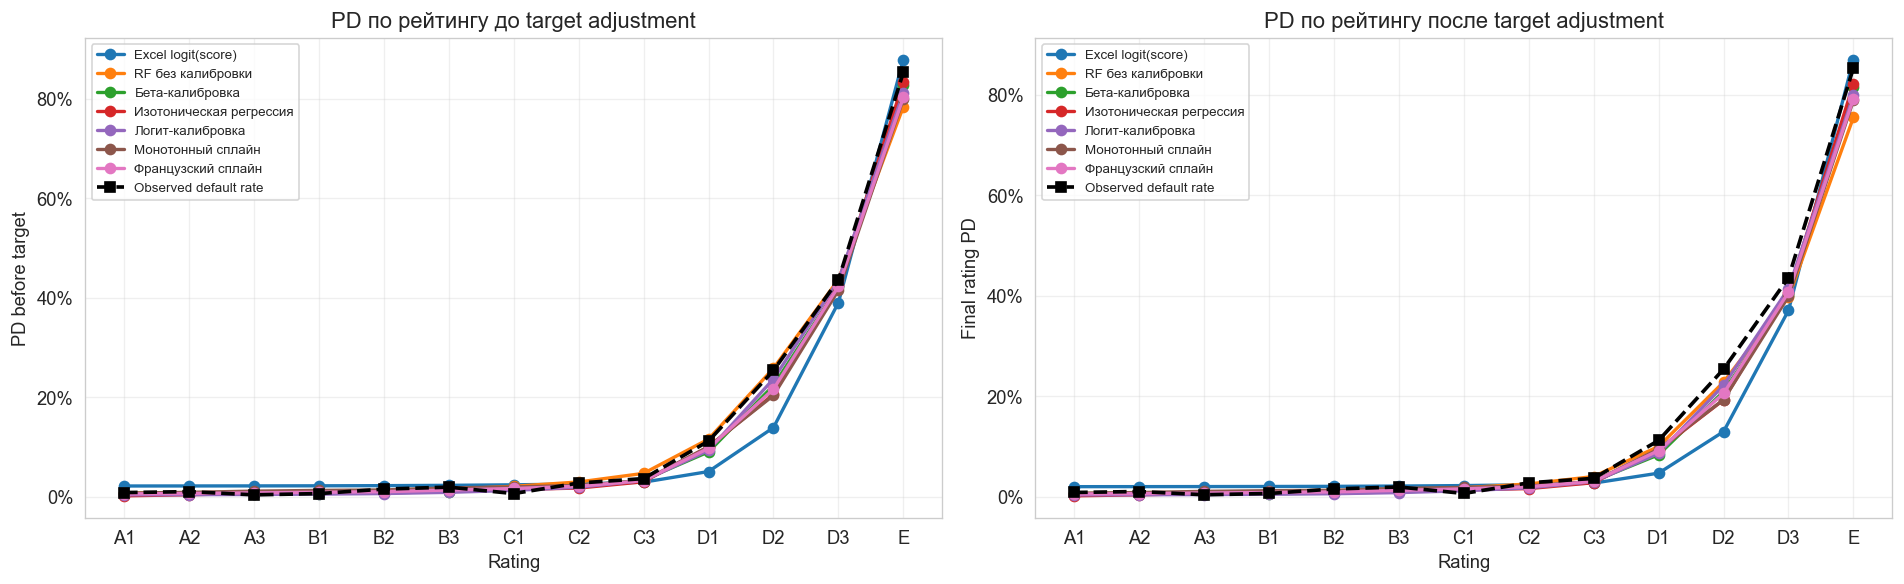

,total_ead,total_expected_loss,total_rwa,total_required_capital,rwa_rate_to_ead
method,,,,,
Excel logit(score),"6,372,000,000","330,245,953","7,557,034,339","604,562,747",118.60%
RF без калибровки,"6,372,000,000","330,245,953","7,428,854,131","594,308,330",116.59%
Бета-калибровка,"6,372,000,000","330,245,953","6,830,349,243","546,427,939",107.19%
Изотоническая регрессия,"6,372,000,000","330,245,953","6,755,990,409","540,479,233",106.03%
Логит-калибровка,"6,372,000,000","330,245,953","6,679,291,234","534,343,299",104.82%
Монотонный сплайн,"6,372,000,000","330,245,953","7,462,052,352","596,964,188",117.11%
Французский сплайн,"6,372,000,000","330,245,953","7,161,165,176","572,893,214",112.38%


In [19]:
# =========================
# Rating Master Scale: сравнение методов
# =========================

# 1. Матрица PD по рейтингам
rating_pd_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="pd_rating")
    .reindex(MASTER_SCALE_RATINGS)
)

# 2. Таблица структуры рейтинговой шкалы
# Берем уникальную структуру по rating, без привязки к одному методу
rating_structure = (
    master_scale_panel[
        [
            "rating",
            "n_assets",
            "portfolio_count_share",
            "observed_default_rate",
        ]
    ]
    .drop_duplicates(subset=["rating"])
    .set_index("rating")
    .reindex(MASTER_SCALE_RATINGS)
)

# 3. Таблица observed DR + PD до target adjustment по всем методам
rating_before_target_matrix = (
    master_scale_panel
    .pivot(index="rating", columns="method", values="pd_before_target")
    .reindex(MASTER_SCALE_RATINGS)
)

# 4. Красивый вывод heatmap-таблицы итоговых PD
display(
    rating_pd_matrix
    .style
    .format("{:.2%}")
    .background_gradient(axis=None, cmap="YlOrRd")
)

# 5. Сводная таблица структуры рейтингов
display(
    rating_structure
    .style.format({
        "portfolio_count_share": "{:.1%}",
        "observed_default_rate": "{:.2%}",
    })
)

# =========================
# ГРАФИК 1: все методы на одном графике
# =========================
fig, ax = plt.subplots(figsize=(11, 6))

for method in rating_pd_matrix.columns:
    ax.plot(
        rating_pd_matrix.index,
        rating_pd_matrix[method],
        marker="o",
        linewidth=2,
        label=method,
    )

# Добавляем observed default rate как ориентир
ax.plot(
    rating_structure.index,
    rating_structure["observed_default_rate"],
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.2,
    label="Observed default rate",
)

ax.set_title("Rating Master Scale: итоговая PD по рейтингу для всех методов")
ax.set_xlabel("Rating")
ax.set_ylabel("PD")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================
# ГРАФИК 2: распределение портфеля и observed DR
# =========================
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    rating_structure.index,
    rating_structure["portfolio_count_share"],
    color=COLORS[1] if "COLORS" in globals() else None,
    alpha=0.75,
    label="Portfolio share",
)

ax2 = ax.twinx()
ax2.plot(
    rating_structure.index,
    rating_structure["observed_default_rate"],
    color=COLORS[0] if "COLORS" in globals() else "black",
    marker="o",
    linewidth=2.2,
    label="Observed default rate",
)

ax.set_title("Распределение портфеля по рейтингам и фактический DR")
ax.set_xlabel("Rating")
ax.set_ylabel("Portfolio share")
ax2.set_ylabel("Observed default rate")

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

plt.tight_layout()
plt.show()

# =========================
# ГРАФИК 3: до и после target adjustment
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 3а. PD до приведения к target CT
ax = axes[0]
for method in rating_before_target_matrix.columns:
    ax.plot(
        rating_before_target_matrix.index,
        rating_before_target_matrix[method],
        marker="o",
        linewidth=2,
        label=method,
    )

ax.plot(
    rating_structure.index,
    rating_structure["observed_default_rate"],
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.2,
    label="Observed default rate",
)

ax.set_title("PD по рейтингу до target adjustment")
ax.set_xlabel("Rating")
ax.set_ylabel("PD before target")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)

# 3б. PD после приведения к target CT
ax = axes[1]
for method in rating_pd_matrix.columns:
    ax.plot(
        rating_pd_matrix.index,
        rating_pd_matrix[method],
        marker="o",
        linewidth=2,
        label=method,
    )

ax.plot(
    rating_structure.index,
    rating_structure["observed_default_rate"],
    color="black",
    linestyle="--",
    marker="s",
    linewidth=2.2,
    label="Observed default rate",
)

ax.set_title("PD по рейтингу после target adjustment")
ax.set_xlabel("Rating")
ax.set_ylabel("Final rating PD")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================
# Таблица капитального эффекта по master scale
# =========================
display(
    master_scale_capital[[
        "total_ead",
        "total_expected_loss",
        "total_rwa",
        "total_required_capital",
        "rwa_rate_to_ead",
    ]]
    .style.format({
        "total_ead": "{:,.0f}",
        "total_expected_loss": "{:,.0f}",
        "total_rwa": "{:,.0f}",
        "total_required_capital": "{:,.0f}",
        "rwa_rate_to_ead": "{:.2%}",
    })
)

каждое наблюдение OOT-портфеля → своя PD → распределение PD по методу

,avg_pd,pd_min,pd_median,pd_max,pd_p95
RF без калибровки,14.06%,0.68%,2.17%,96.60%,75.05%
Логит-калибровка,13.47%,0.35%,1.33%,97.88%,78.23%
Изотоническая регрессия,13.43%,0.00%,1.33%,100.00%,82.56%
Бета-калибровка,13.46%,0.45%,1.50%,98.87%,80.03%
Монотонный сплайн,13.38%,0.74%,2.05%,88.44%,79.28%
Французский сплайн,13.36%,0.57%,1.72%,89.49%,78.91%


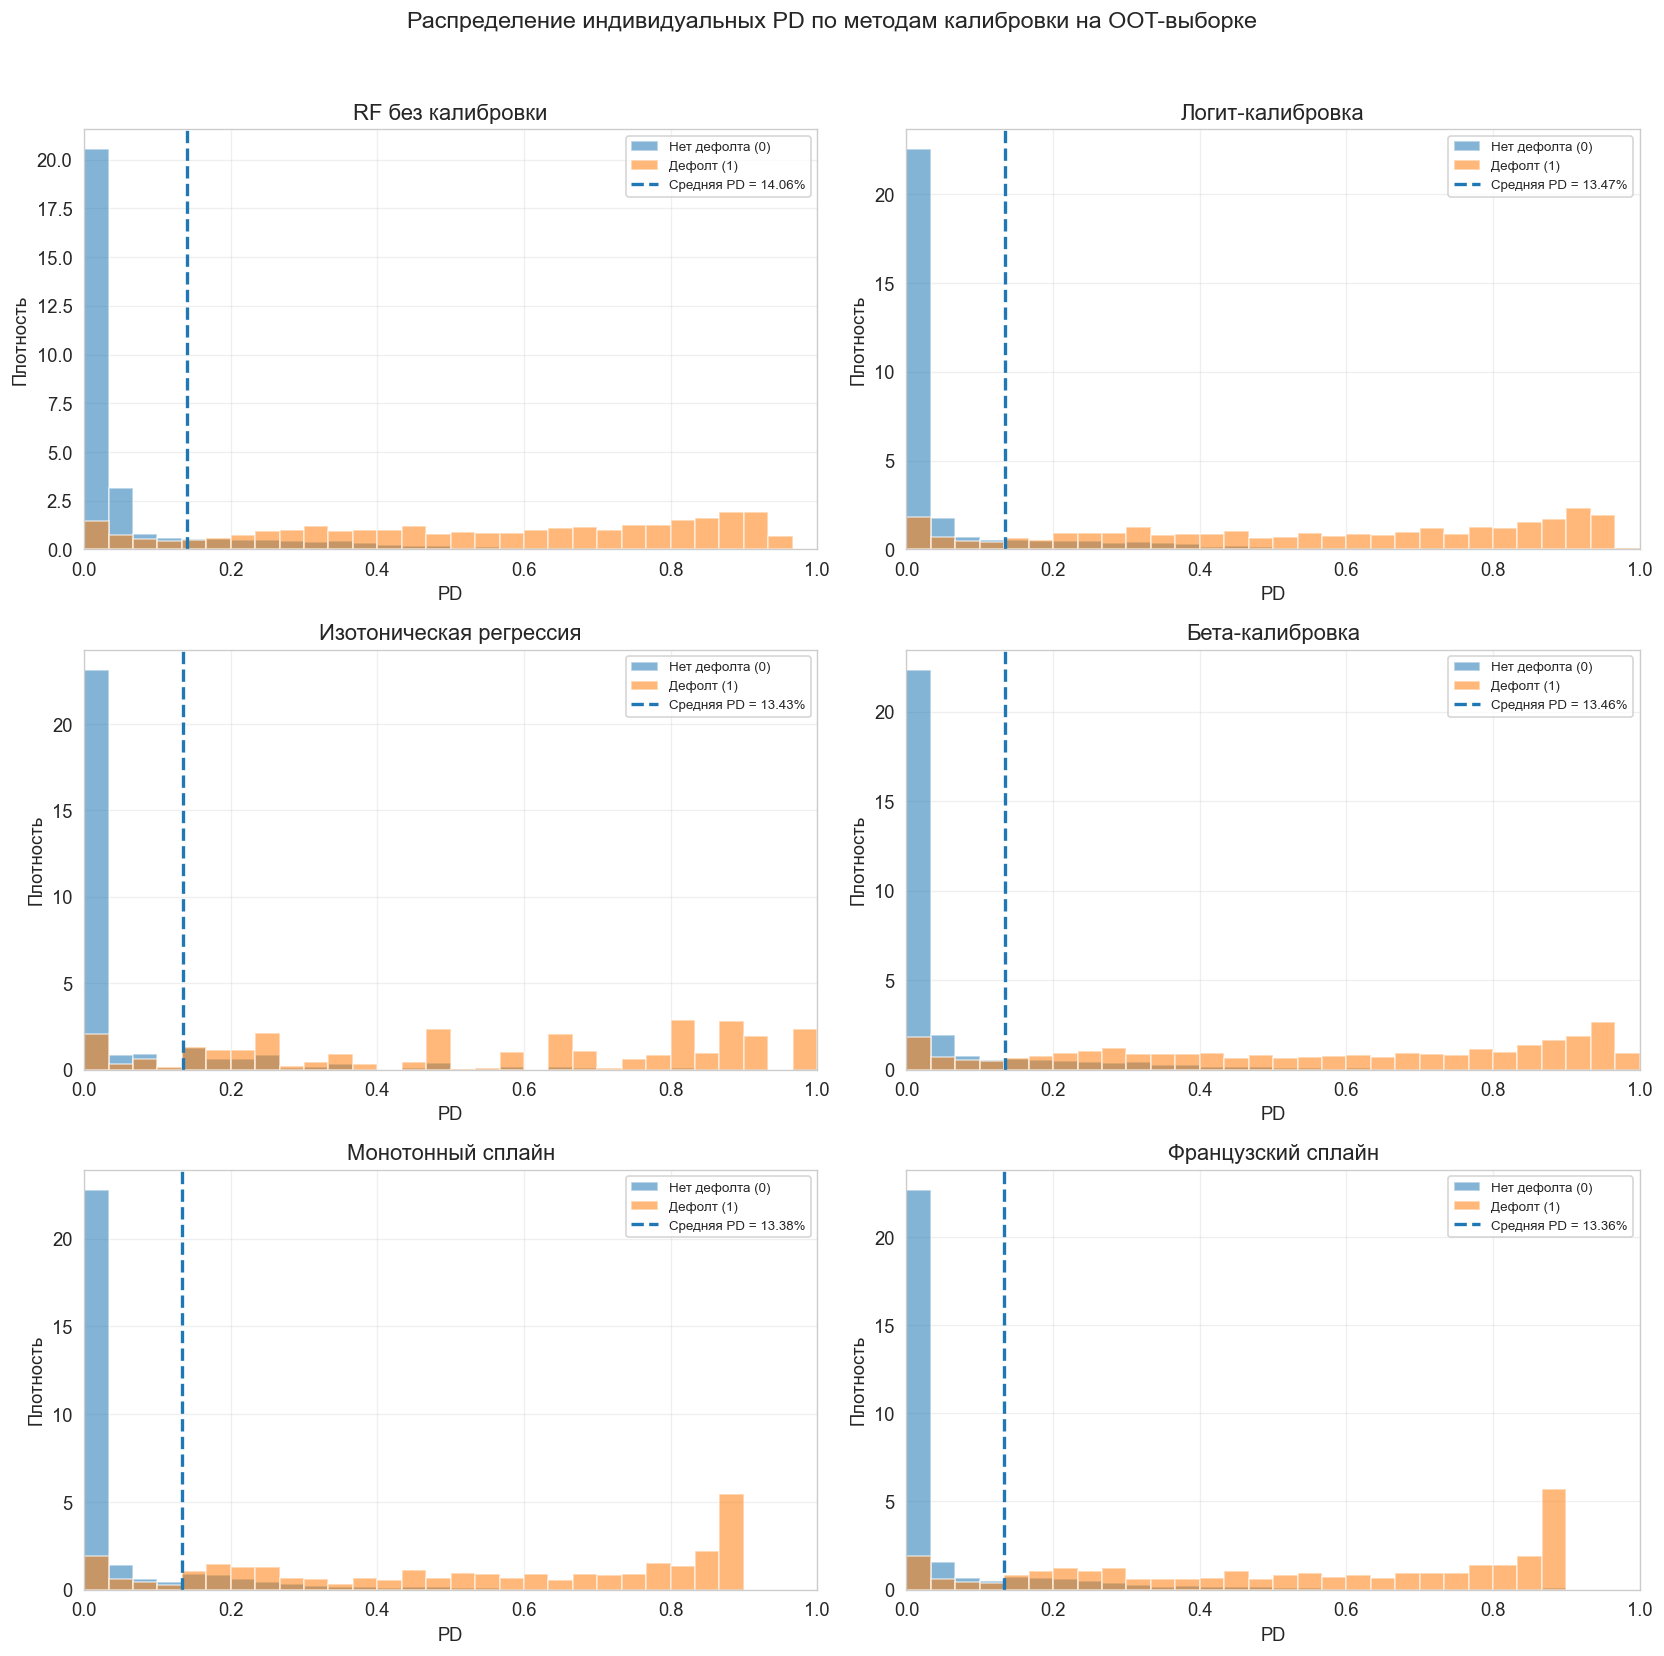

In [20]:
# =========================
# Распределение индивидуальных PD по каждому методу на OOT-выборке
# =========================

pd_distribution_predictions = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

pd_distribution_df = pd.DataFrame(pd_distribution_predictions)
pd_distribution_df["default"] = y_test.values

# 1. Краткая таблица распределения PD по методам
pd_distribution_summary = (
    pd_distribution_df
    .drop(columns="default")
    .agg(["mean", "min", "median", "max", lambda x: np.quantile(x, 0.95)])
    .T
    .rename(columns={
        "mean": "avg_pd",
        "min": "pd_min",
        "median": "pd_median",
        "max": "pd_max",
        "<lambda>": "pd_p95",
    })
)

display(
    pd_distribution_summary
    .style.format("{:.2%}")
)

# 2. Единые бины, чтобы графики были сопоставимы
bins = np.linspace(0, 1, 31)

n_methods = len(pd_distribution_predictions)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, (method, probs) in enumerate(pd_distribution_predictions.items()):
    ax = axes[i]

    probs = np.asarray(probs)
    probs_good = probs[y_test.values == 0]
    probs_bad = probs[y_test.values == 1]

    ax.hist(
        probs_good,
        bins=bins,
        alpha=0.55,
        density=True,
        label="Нет дефолта (0)",
    )

    ax.hist(
        probs_bad,
        bins=bins,
        alpha=0.55,
        density=True,
        label="Дефолт (1)",
    )

    ax.axvline(
        probs.mean(),
        linestyle="--",
        linewidth=2,
        label=f"Средняя PD = {probs.mean():.2%}",
    )

    ax.set_title(method)
    ax.set_xlabel("PD")
    ax.set_ylabel("Плотность")
    ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Удаляем пустые графики, если число методов нечетное
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Распределение индивидуальных PD по методам калибровки на OOT-выборке",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()

In [21]:
# =========================
# Эффект калибровки на EL, UL capital, RWA и Н1.0
# =========================

pred_map = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

capital_assumptions = IRBAssumptions(
    lgd=0.40,
    maturity_years=2.5,
    ead=1_000_000.0,
)

# Расчет IRB-style capital / RWA по каждому методу PD
df_rwa = compare_irb_capital_by_method(
    pred_map,
    assumptions=capital_assumptions,
    baseline_method="RF без калибровки",
)

# Капитал, который требуется для RF без калибровки
# В данной логике это 8% * RWA_RF, то есть required capital для базовой модели
base_required_capital_rf = df_rwa.loc[
    "RF без калибровки",
    "total_required_capital"
]

# Гипотетический Н1.0:
# что будет, если капитал оставить как у RF,
# а RWA пересчитать по каждому методу калибровки
df_rwa["h1_0_if_keep_rf_capital"] = (
    base_required_capital_rf / df_rwa["total_rwa"]
)

# Прирост Н1.0 относительно норматива 8%
df_rwa["h1_0_uplift_vs_norm"] = (
    df_rwa["h1_0_if_keep_rf_capital"]
    - capital_assumptions.capital_ratio
)

# Сортируем по требуемому капиталу: сверху методы с меньшей капитальной нагрузкой
df_rwa = df_rwa.sort_values("total_required_capital")


print(f"Для каждого наблюдения принят фиксированный EAD = {capital_assumptions.ead:,.0f}")
print(f"LGD = {capital_assumptions.lgd:.0%}")
print(f"M = {capital_assumptions.maturity_years:.1f}")
print(f"Норматив достаточности капитала Н1.0 = {capital_assumptions.capital_ratio:.0%}")
print()
print("Логика расчета:")
print("EL / Reserves = PD × LGD × EAD")
print("UL capital = K × EAD")
print("RWA = UL capital / Н1.0 = UL capital / 8% = UL capital × 12.5")
print("Required capital = 8% × RWA = UL capital")
print("Н1.0 при капитале RF = капитал RF / RWA метода\n")


# =========================
# Таблица для вывода
# =========================

display_cols = [
    "avg_pd",
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "h1_0_if_keep_rf_capital",
    "h1_0_uplift_vs_norm",
]

df_rwa_display = df_rwa[display_cols].copy()

# Процентные показатели переводим в %
percent_cols = [
    "avg_pd",
    "rwa_saving_vs_baseline_pct",
    "capital_saving_vs_baseline_pct",
    "h1_0_if_keep_rf_capital",
    "h1_0_uplift_vs_norm",
]

for col in percent_cols:
    df_rwa_display[col] = (100 * df_rwa_display[col]).round(2)

# Денежные показатели переводим в млрд
money_cols = [
    "total_ead",
    "total_expected_loss",
    "total_unexpected_loss_capital",
    "total_rwa",
    "total_required_capital",
]

for col in money_cols:
    df_rwa_display[col] = (df_rwa_display[col] / 1_000_000_000).round(3)

df_rwa_display = df_rwa_display.rename(columns={
    "avg_pd": "Средняя PD, %",
    "total_ead": "EAD, млрд",
    "total_expected_loss": "EL / Reserves, млрд",
    "total_unexpected_loss_capital": "UL capital, млрд",
    "total_rwa": "RWA, млрд",
    "total_required_capital": "Треб. капитал, млрд",
    "rwa_saving_vs_baseline_pct": "Изм. RWA vs RF, %",
    "capital_saving_vs_baseline_pct": "Изм. капитала vs RF, %",
    "h1_0_if_keep_rf_capital": "Н1.0 при капитале RF, %",
    "h1_0_uplift_vs_norm": "Прирост Н1.0 к 8%, п.п.",
})

display(df_rwa_display)


# =========================
# Проверка формулы на первых 3 наблюдениях RF
# =========================

print("Первые 3 строки IRB-style расчета для RF без калибровки:")
print("Важно: unexpected_loss_capital — это аналог RWA_capital из учебного кода, а не сам RWA.")
print("Сам RWA получается как unexpected_loss_capital / 8%.\n")

irb_check = calculate_irb_capital(
    scores_test[:3],
    assumptions=capital_assumptions
)

display(
    irb_check[[
        "pd",
        "ead",
        "expected_loss",
        "asset_correlation",
        "maturity_adjustment",
        "unexpected_loss_capital",
        "rwa",
        "required_capital",
    ]]
    .style.format({
        "pd": "{:.4%}",
        "ead": "{:,.0f}",
        "expected_loss": "{:,.2f}",
        "asset_correlation": "{:.4f}",
        "maturity_adjustment": "{:.4f}",
        "unexpected_loss_capital": "{:,.2f}",
        "rwa": "{:,.2f}",
        "required_capital": "{:,.2f}",
    })
)

Для каждого наблюдения принят фиксированный EAD = 1,000,000
LGD = 40%
M = 2.5
Норматив достаточности капитала Н1.0 = 8%

Логика расчета:
EL / Reserves = PD × LGD × EAD
UL capital = K × EAD
RWA = UL capital / Н1.0 = UL capital / 8% = UL capital × 12.5
Required capital = 8% × RWA = UL capital
Н1.0 при капитале RF = капитал RF / RWA метода



,"Средняя PD, %","EAD, млрд","EL / Reserves, млрд","UL capital, млрд","RWA, млрд","Треб. капитал, млрд","Изм. RWA vs RF, %","Изм. капитала vs RF, %","Н1.0 при капитале RF, %","Прирост Н1.0 к 8%, п.п."
method,,,,,,,,,,
Логит-калибровка,13.47,6.372,0.343,0.537,6.708,0.537,11.21,11.21,9.01,1.01
Изотоническая регрессия,13.43,6.372,0.342,0.540,6.754,0.540,10.61,10.61,8.95,0.95
Бета-калибровка,13.46,6.372,0.343,0.549,6.866,0.549,9.12,9.12,8.80,0.80
Французский сплайн,13.36,6.372,0.341,0.574,7.174,0.574,5.04,5.04,8.42,0.42
Монотонный сплайн,13.38,6.372,0.341,0.598,7.476,0.598,1.05,1.05,8.08,0.08
RF без калибровки,14.06,6.372,0.358,0.604,7.555,0.604,0.00,0.00,8.00,-0.00


Первые 3 строки IRB-style расчета для RF без калибровки:
Важно: unexpected_loss_capital — это аналог RWA_capital из учебного кода, а не сам RWA.
Сам RWA получается как unexpected_loss_capital / 8%.



,pd,ead,expected_loss,asset_correlation,maturity_adjustment,unexpected_loss_capital,rwa,required_capital
0,1.3181%,"1,000,000","5,272.57",0.1821,1.2342,"72,105.82","901,322.79","72,105.82"
1,1.7084%,"1,000,000","6,833.62",0.1711,1.2120,"78,069.43","975,867.85","78,069.43"
2,0.9180%,"1,000,000","3,672.05",0.1958,1.2682,"63,630.88","795,386.05","63,630.88"


В данном блоке 8% трактуется как норматив достаточности капитала Н1.0, рассчитываемый по формуле `Н1.0 = капитал / RWA`. Поэтому RWA определяется как `UL capital / 8%`, то есть `UL capital × 12.5`. Показатель `required capital` равен `8% × RWA`, поэтому по конструкции совпадает с `UL capital`.

Показатель `Н1.0 при капитале RF` показывает, каким стал бы норматив достаточности капитала, если сохранить капитал, достаточный для RF без калибровки, но пересчитать RWA по каждому методу калибровки. Поэтому рост этого показателя отражает потенциальное высвобождение капитала за счет снижения RWA.

### Расчет по формуле 845-П в формате ментора

Ниже сохранен рекомендованный ментором блок расчета. Перед ним создается `data_ocp` с теми именами колонок, которые ожидает исходный код: `FRAT_FINAL_PD`, `EAD`, `DEFAULT_DURING_NEXT_YEAR`. В качестве `FRAT_FINAL_PD` используется финальная калиброванная PD-шкала из текущего эксперимента.

In [22]:
final_pd_method = list(calibrated_probs.keys())[-1]
print(f"Финальная PD для расчета 845-П: {final_pd_method}")

data_ocp = pd.DataFrame({
    "FRAT_FINAL_PD": calibrated_probs[final_pd_method],
    "EAD": np.full(len(y_test), capital_assumptions.ead, dtype=float),
    "DEFAULT_DURING_NEXT_YEAR": y_test.values.astype(float),
})

# Используем формулы из 845-П
data_ocp['Reserves'] = data_ocp.FRAT_FINAL_PD * 0.4 * data_ocp.EAD
data_ocp['R'] = 0.12*(np.divide(1-np.exp(-50*data_ocp.FRAT_FINAL_PD), 1-np.exp(-50))) + 0.24*(1-np.divide(1-np.exp(-50*data_ocp.FRAT_FINAL_PD), 1-np.exp(-50)))
data_ocp['RWA_capital'] = data_ocp.EAD * 0.4 * (norm.cdf(np.divide(norm.ppf(data_ocp.FRAT_FINAL_PD)+(data_ocp.R)**0.5*norm.ppf(0.999),((1-data_ocp.R)**0.5)) - data_ocp.FRAT_FINAL_PD) * np.divide(1, 1-1.5*(0.11852-0.05478*np.log(data_ocp.FRAT_FINAL_PD))**2))
data_ocp['Capital_true'] = np.where(data_ocp.DEFAULT_DURING_NEXT_YEAR == 1.0, 0.4*data_ocp.EAD, data_ocp.Reserves + data_ocp.RWA_capital)
data_ocp.head(3)

Финальная PD для расчета 845-П: Французский сплайн


,FRAT_FINAL_PD,EAD,DEFAULT_DURING_NEXT_YEAR,Reserves,R,RWA_capital,Capital_true
0,0.011241,1000000.0,0.0,4496.361098,0.188405,72718.748145,77215.109243
1,0.014630,1000000.0,0.0,5851.900741,0.177743,79903.703490,85755.604232
2,0.008334,1000000.0,0.0,3333.756464,0.199105,64721.135390,68054.891855


### Ограничения RWA-блока

Расчет ниже нужен для оценки чувствительности капитала к калиброванной PD, а не для полноценной регуляторной отчетности.

Ключевые упрощения:

- используется Basel-style IRB формула для иллюстрации, а не полный production IRB контур банка;
- `EAD`, `LGD` и `M` фиксированы, чтобы изолировать именно эффект PD;
- не моделируются downturn LGD, CRM, guarantees, collateral, defaulted assets и сегментные регуляторные нюансы;
- синтетический портфель нужен для демонстрации методологии, а не для оценки реального банка.

Поэтому результаты RWA следует читать как **сравнительный эффект калибровки**, а не как абсолютный норматив капитала.

#### Визуализация эффекта на RWA и капитал

Ниже показано, как различия в калиброванной `PD` отражаются на:
- резервах;
- имплицитном `RWA`;
- требуемом капитале при `H1 = 8%`;
- экономии капитала относительно сырых `PD`;
- значении `H1`, если сохранить капитал, достаточный для ванильной модели.

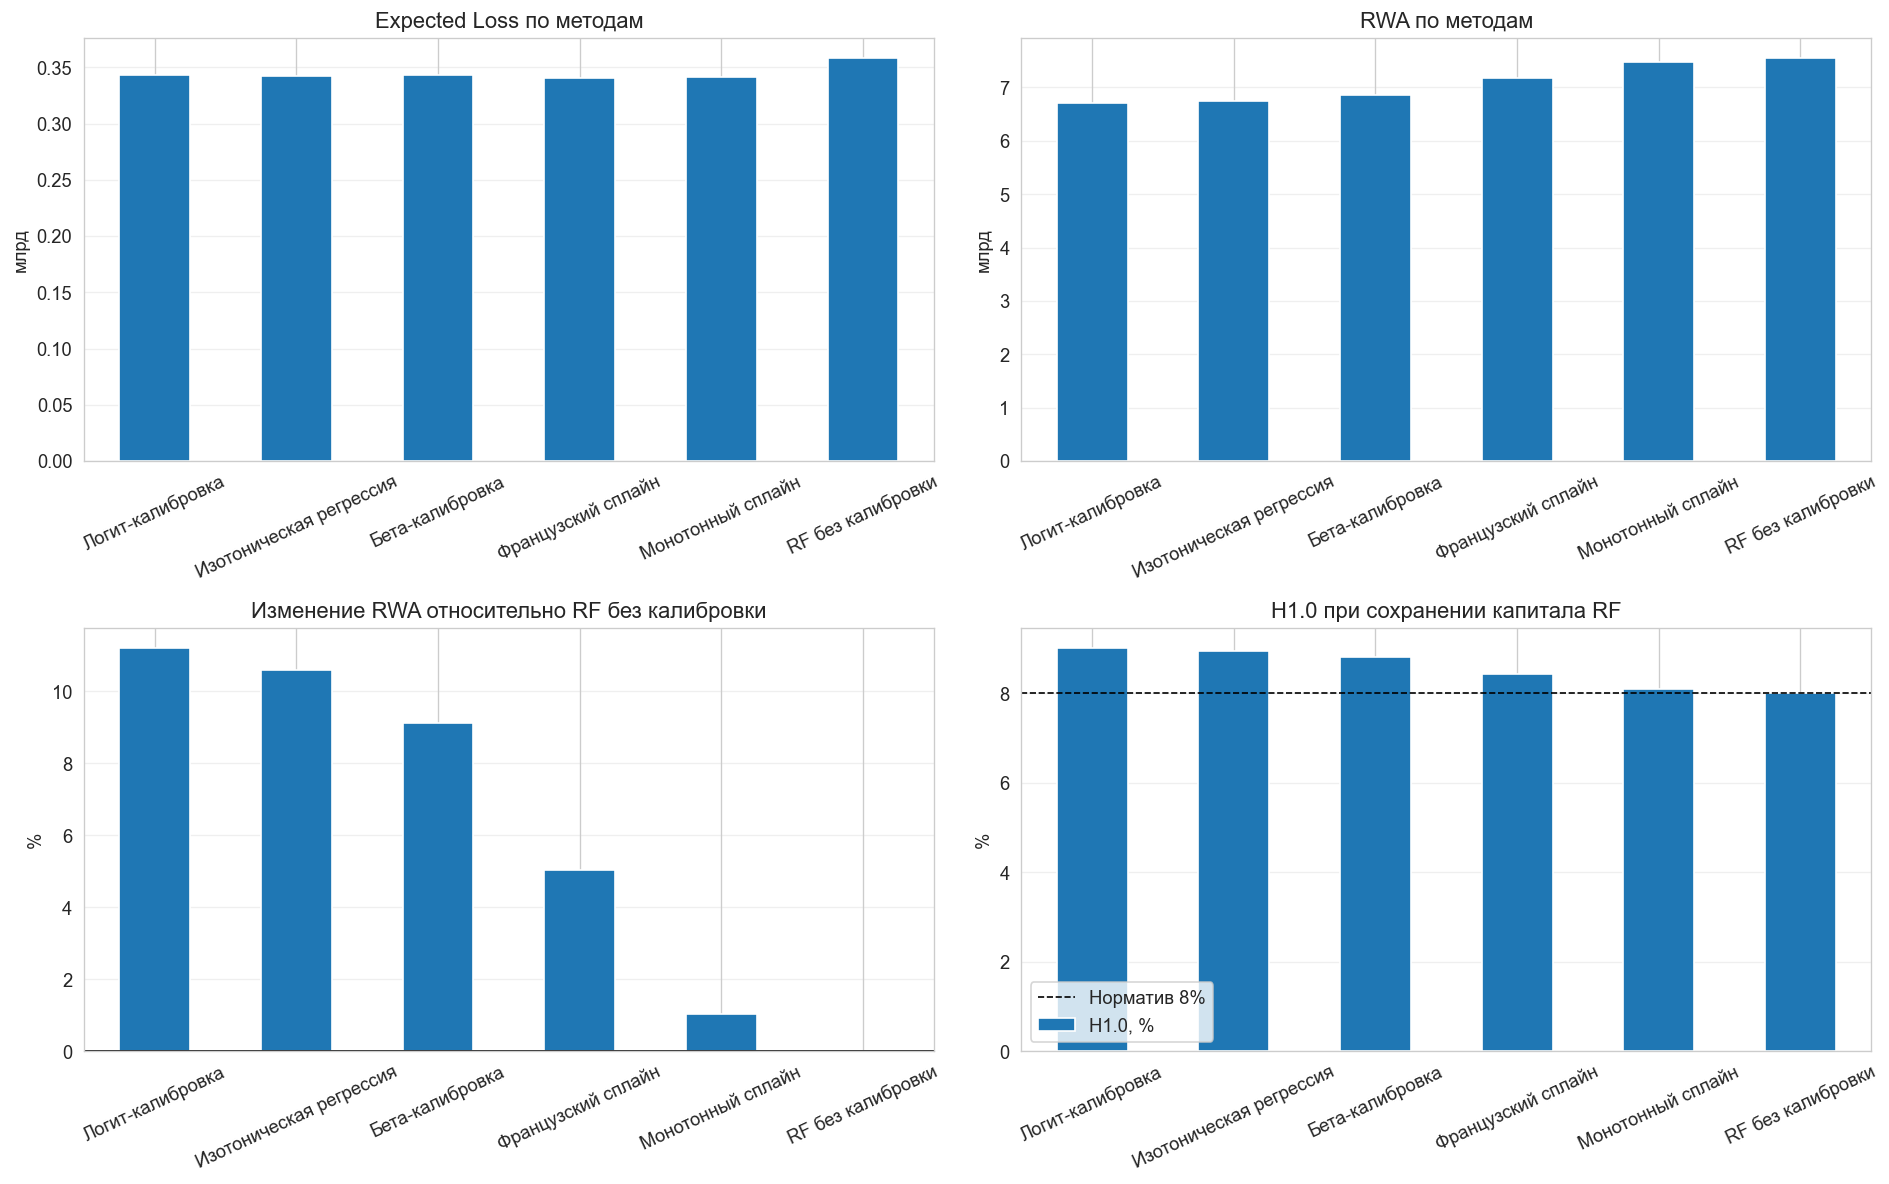

In [23]:
# =========================
# Компактная визуализация capital impact
# =========================

plot_df = df_rwa.reset_index().copy()

plot_df["EL, млрд"] = plot_df["total_expected_loss"] / 1_000_000_000
plot_df["RWA, млрд"] = plot_df["total_rwa"] / 1_000_000_000
plot_df["Изм. RWA vs RF, %"] = 100 * plot_df["rwa_saving_vs_baseline_pct"]
plot_df["Н1.0, %"] = 100 * plot_df["h1_0_if_keep_rf_capital"]

# Если хочешь дополнительно видеть риск-вес портфеля:
plot_df["RWA / EAD, %"] = 100 * (plot_df["total_rwa"] / plot_df["total_ead"])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Expected Loss
plot_df.plot(
    x="method",
    y="EL, млрд",
    kind="bar",
    ax=axes[0, 0],
    legend=False,
    rot=25,
    title="Expected Loss по методам"
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("млрд")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. RWA
plot_df.plot(
    x="method",
    y="RWA, млрд",
    kind="bar",
    ax=axes[0, 1],
    legend=False,
    rot=25,
    title="RWA по методам"
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("млрд")
axes[0, 1].grid(axis="y", alpha=0.3)

# 3. Изменение RWA vs RF
plot_df.plot(
    x="method",
    y="Изм. RWA vs RF, %",
    kind="bar",
    ax=axes[1, 0],
    legend=False,
    rot=25,
    title="Изменение RWA относительно RF без калибровки"
)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("%")
axes[1, 0].grid(axis="y", alpha=0.3)

# 4. Н1.0 при сохранении капитала RF
plot_df.plot(
    x="method",
    y="Н1.0, %",
    kind="bar",
    ax=axes[1, 1],
    legend=False,
    rot=25,
    title="Н1.0 при сохранении капитала RF"
)
axes[1, 1].axhline(
    100 * capital_assumptions.capital_ratio,
    color="black",
    lw=1,
    linestyle="--",
    label="Норматив 8%"
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("%")
axes[1, 1].grid(axis="y", alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 7. Оценка устойчивости результатов

При близких значениях метрик точечные оценки сами по себе могут вводить в заблуждение. Поэтому устойчивость результатов проверяется через **bootstrap confidence intervals** для Brier Score и AUC.

Если доверительные интервалы методов существенно перекрываются, это означает, что различия между ними малы и не дают оснований объявлять одного явного победителя только по одной точечной метрике.

In [24]:
from sklearn.metrics import roc_auc_score

boot_rows = []

print("Bootstrap 95% CI (1000 итераций) на OOT Test...")
print(f"{'Метод':<28} {'Brier':>7}  {'95% CI Brier':>18}  {'AUC':>7}  {'95% CI AUC':>18}")
print("-" * 85)

for name, probs in all_preds.items():
    ci_brier = bootstrap_ci(y_test.values, probs, brier_score,   n_iter=1000, random_state=42)
    ci_auc   = bootstrap_ci(y_test.values, probs, roc_auc_score, n_iter=1000, random_state=42)

    boot_rows.append({
        "method": name,
        "brier_point": ci_brier["point_estimate"],
        "brier_ci_lower": ci_brier["ci_lower"],
        "brier_ci_upper": ci_brier["ci_upper"],
        "auc_point": ci_auc["point_estimate"],
        "auc_ci_lower": ci_auc["ci_lower"],
        "auc_ci_upper": ci_auc["ci_upper"],
    })

    print(
        f"{name:<28} "
        f"{ci_brier['point_estimate']:>7.5f}  "
        f"[{ci_brier['ci_lower']:.5f}, {ci_brier['ci_upper']:.5f}]  "
        f"{ci_auc['point_estimate']:>7.4f}  "
        f"[{ci_auc['ci_lower']:.4f}, {ci_auc['ci_upper']:.4f}]"
    )

df_boot = pd.DataFrame(boot_rows).set_index("method")

print("\nИнтерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.")


Bootstrap 95% CI (1000 итераций) на OOT Test...
Метод                          Brier        95% CI Brier      AUC          95% CI AUC
-------------------------------------------------------------------------------------


RF без калибровки            0.06134  [0.05753, 0.06528]   0.9316  [0.9220, 0.9412]


Логит-калибровка             0.06105  [0.05702, 0.06509]   0.9316  [0.9220, 0.9412]


Изотоническая регрессия      0.06094  [0.05678, 0.06511]   0.9313  [0.9216, 0.9408]


Бета-калибровка              0.06103  [0.05692, 0.06515]   0.9316  [0.9220, 0.9412]


Монотонный сплайн            0.06126  [0.05714, 0.06536]   0.9315  [0.9219, 0.9413]


Французский сплайн           0.06114  [0.05705, 0.06524]   0.9316  [0.9220, 0.9412]

Интерпретация: если интервалы по Brier заметно перекрываются, различия между методами невелики.


### Анализ по полной шкале вероятностей

Ниже калибровка и распределение PD показаны **на всей шкале [0; 1]**, а не только в той области, где сосредоточена основная масса наблюдений.  
Дополнительно для каждого метода строится таблица фиксированных биннов `[0.0–0.1], …, [0.9–1.0]`, чтобы увидеть, **как именно модель распределяет наблюдения и дефолты по всей шкале риска**.


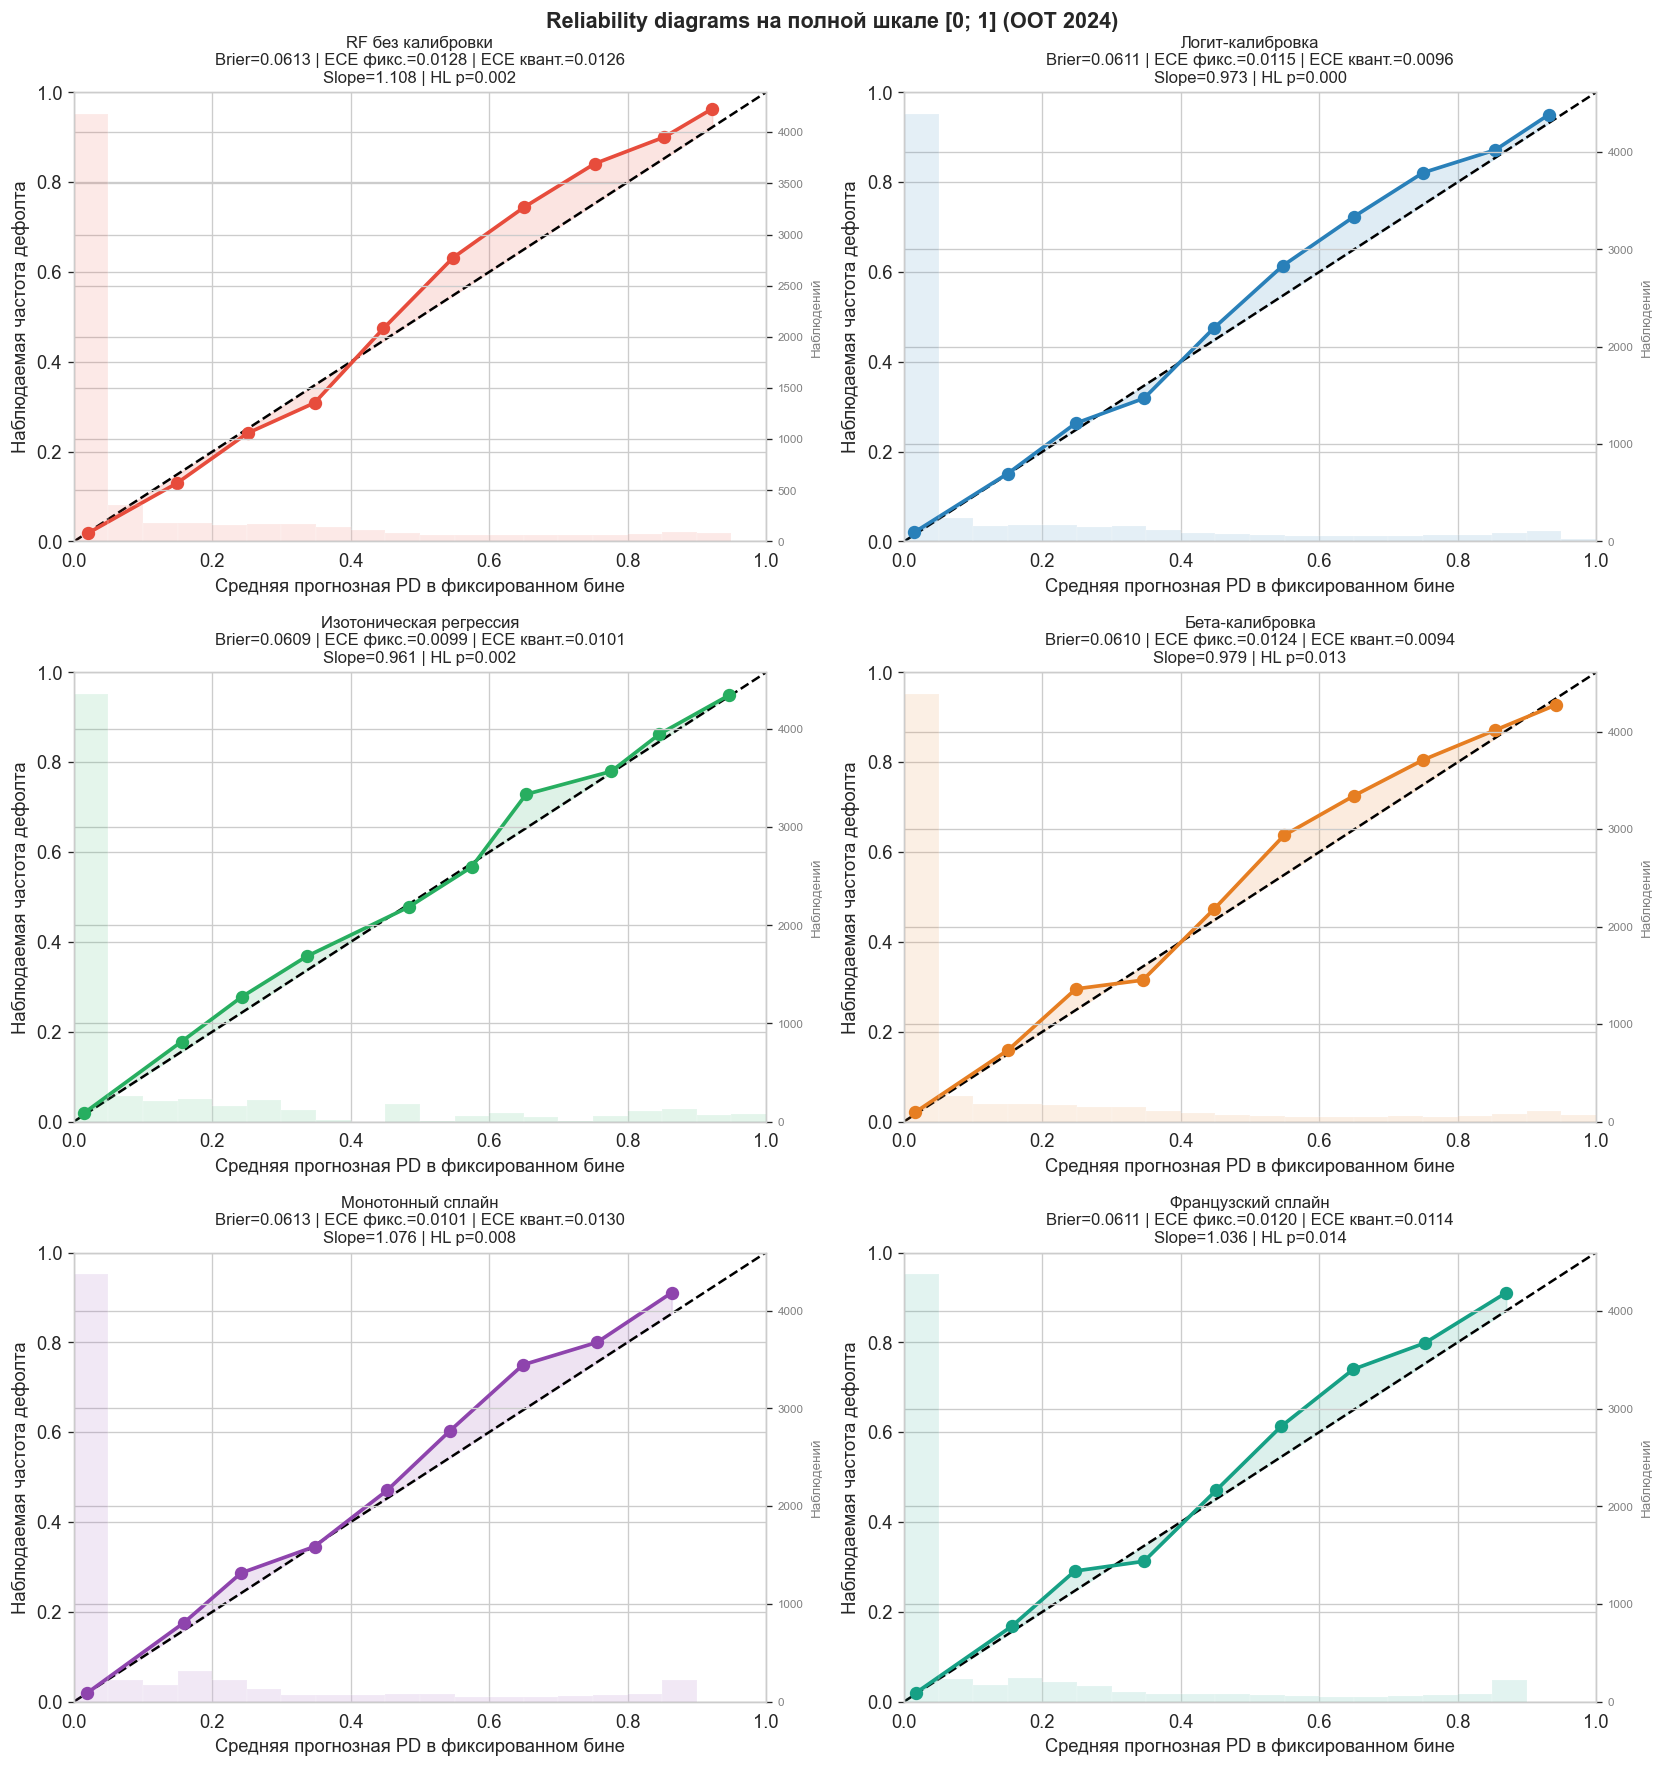

Распределение наблюдений и дефолтов по фиксированным бинам на полной шкале [0; 1]:

RF без калибровки
          bin    n  share  avg_pd  default_rate  defaults
(-0.001, 0.1] 4536  71.19  0.0201        0.0183        83
   (0.1, 0.2]  354   5.56  0.1490        0.1299        46
   (0.2, 0.3]  340   5.34  0.2510        0.2412        82
   (0.3, 0.4]  311   4.88  0.3478        0.3087        96
   (0.4, 0.5]  194   3.04  0.4473        0.4742        92
   (0.5, 0.6]  125   1.96  0.5480        0.6320        79
   (0.6, 0.7]  133   2.09  0.6506        0.7444        99
   (0.7, 0.8]  126   1.98  0.7526        0.8413       106
   (0.8, 0.9]  171   2.68  0.8533        0.9006       154
   (0.9, 1.0]   82   1.29  0.9224        0.9634        79

Логит-калибровка
          bin    n  share  avg_pd  default_rate  defaults
(-0.001, 0.1] 4637  72.77  0.0145        0.0201        93
   (0.1, 0.2]  324   5.08  0.1499        0.1512        49
   (0.2, 0.3]  323   5.07  0.2480        0.2632        85
   (0.3, 0

In [25]:
all_methods = {"RF без калибровки": scores_test, **calibrated_probs}

n_methods = len(all_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (name, probs) in enumerate(all_methods.items()):
    ax = axes[i]
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    m = summary_metrics(y_test.values, probs)

    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.plot(mean_pred, frac_pos, "o-", color=COLORS[i], lw=2.2, ms=7)
    ax.fill_between(mean_pred, mean_pred, frac_pos, alpha=0.15, color=COLORS[i])

    ax2 = ax.twinx()
    ax2.hist(probs, bins=np.linspace(0, 1, 21), alpha=0.12, color=COLORS[i])
    ax2.set_ylabel("Наблюдений", fontsize=8, color="gray")
    ax2.tick_params(axis="y", labelsize=7, labelcolor="gray")

    subtitle = (
        f'Brier={m["brier_score"]:.4f} | ECE фикс.={m["ece_uniform"]:.4f} | ECE квант.={m["ece_quantile"]:.4f}\n'
        f'Slope={m["cal_slope"]:.3f} | HL p={m["hl_p_value"]:.3f}'
    )
    ax.set_title(f"{name}\n{subtitle}", fontsize=10)
    ax.set_xlabel("Средняя прогнозная PD в фиксированном бине")
    ax.set_ylabel("Наблюдаемая частота дефолта")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Reliability diagrams на полной шкале [0; 1] (OOT 2024)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Распределение наблюдений и дефолтов по фиксированным бинам на полной шкале [0; 1]:")
for name, probs in all_methods.items():
    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)
    bin_table = fixed_bin_table(y_test.values, probs, n_bins=10).copy()
    bin_table["share"] = (100 * bin_table["share"]).round(2)
    bin_table["avg_pd"] = bin_table["avg_pd"].round(4)
    bin_table["default_rate"] = bin_table["default_rate"].round(4)
    print(bin_table.to_string(index=False))

Проверка изотоники

In [26]:
# =========================
# Диагностика "выброса" изотонической регрессии в диапазоне PD 0.6–0.7
# =========================

iso_probs = calibrated_probs["Изотоническая регрессия"]

# Таблица фиксированных бинов именно для изотонической регрессии
iso_bin_table = fixed_bin_table(y_test.values, iso_probs, n_bins=10).copy()

display(
    iso_bin_table
    .style.format({
        "share": "{:.2%}",
        "avg_pd": "{:.4f}",
        "default_rate": "{:.4f}",
    })
)

# Фокус на проблемном бине
low, high = 0.6, 0.7
focus_mask = (iso_probs > low) & (iso_probs <= high)

n_focus = int(focus_mask.sum())
defaults_focus = int(y_test.values[focus_mask].sum())
avg_pd_focus = float(iso_probs[focus_mask].mean())
dr_focus = float(y_test.values[focus_mask].mean())

# Оценка стандартной ошибки для observed default rate
se_focus = np.sqrt(dr_focus * (1 - dr_focus) / n_focus) if n_focus > 0 else np.nan
ci_low = dr_focus - 1.96 * se_focus
ci_high = dr_focus + 1.96 * se_focus

print(f"Изотоническая регрессия: бин ({low}; {high}]")
print(f"Наблюдений в бине: {n_focus}")
print(f"Дефолтов в бине: {defaults_focus}")
print(f"Средняя PD в бине: {avg_pd_focus:.2%}")
print(f"Фактическая доля дефолтов: {dr_focus:.2%}")
print(f"Отклонение default_rate - avg_pd: {(dr_focus - avg_pd_focus):.2%}")
print(f"Приблизительный 95% CI для default_rate: [{ci_low:.2%}; {ci_high:.2%}]")

,bin,n,share,avg_pd,default_rate,defaults
0,"(-0.001, 0.1]",4618,72.47%,0.0151,0.0195,90
1,"(0.1, 0.2]",438,6.87%,0.1557,0.1781,78
2,"(0.2, 0.3]",382,5.99%,0.2424,0.2775,106
3,"(0.3, 0.4]",136,2.13%,0.3362,0.3676,50
4,"(0.4, 0.5]",178,2.79%,0.4837,0.4775,85
5,"(0.5, 0.6]",60,0.94%,0.5747,0.5667,34
6,"(0.6, 0.7]",129,2.02%,0.6534,0.7287,94
7,"(0.7, 0.8]",59,0.93%,0.7763,0.7797,46
8,"(0.8, 0.9]",233,3.66%,0.8460,0.8627,201
9,"(0.9, 1.0]",139,2.18%,0.9471,0.9496,132


Изотоническая регрессия: бин (0.6; 0.7]
Наблюдений в бине: 129
Дефолтов в бине: 94
Средняя PD в бине: 65.34%
Фактическая доля дефолтов: 72.87%
Отклонение default_rate - avg_pd: 7.52%
Приблизительный 95% CI для default_rate: [65.20%; 80.54%]


In [27]:
# =========================
# Проверка: проблема появилась на OOT или уже была на calibration?
# =========================

iso_calib_probs = calibrators["Изотоническая регрессия"].predict(scores_calib)

calib_focus_mask = (iso_calib_probs > low) & (iso_calib_probs <= high)
test_focus_mask = focus_mask

compare_focus = pd.DataFrame([
    {
        "sample": "Calibration 2022–2023",
        "n": int(calib_focus_mask.sum()),
        "avg_pd": float(iso_calib_probs[calib_focus_mask].mean()),
        "default_rate": float(y_calib.values[calib_focus_mask].mean()),
        "defaults": int(y_calib.values[calib_focus_mask].sum()),
    },
    {
        "sample": "OOT 2024",
        "n": int(test_focus_mask.sum()),
        "avg_pd": float(iso_probs[test_focus_mask].mean()),
        "default_rate": float(y_test.values[test_focus_mask].mean()),
        "defaults": int(y_test.values[test_focus_mask].sum()),
    },
])

compare_focus["gap"] = compare_focus["default_rate"] - compare_focus["avg_pd"]

display(
    compare_focus
    .style.format({
        "avg_pd": "{:.2%}",
        "default_rate": "{:.2%}",
        "gap": "{:.2%}",
    })
)

,sample,n,avg_pd,default_rate,defaults,gap
0,Calibration 2022–2023,293,65.19%,65.19%,191,0.00%
1,OOT 2024,129,65.34%,72.87%,94,7.52%


In [28]:
# =========================
# Проверка ступеней изотонической регрессии в проблемном диапазоне
# =========================

iso_focus_df = pd.DataFrame({
    "iso_pd": iso_probs[focus_mask],
    "raw_rf_score": scores_test[focus_mask],
    "default": y_test.values[focus_mask],
})

iso_focus_df["iso_pd_rounded"] = iso_focus_df["iso_pd"].round(4)

iso_steps = (
    iso_focus_df
    .groupby("iso_pd_rounded")
    .agg(
        n=("default", "size"),
        defaults=("default", "sum"),
        default_rate=("default", "mean"),
        avg_raw_rf_score=("raw_rf_score", "mean"),
    )
    .sort_index()
)

display(
    iso_steps
    .style.format({
        "default_rate": "{:.2%}",
        "avg_raw_rf_score": "{:.4f}",
    })
)

,n,defaults,default_rate,avg_raw_rf_score
iso_pd_rounded,,,,
0.641100,85,61,71.76%,0.5925
0.646900,1,1,100.00%,0.6285
0.666700,14,8,57.14%,0.6343
0.683300,29,24,82.76%,0.6514


Проверка изотоники

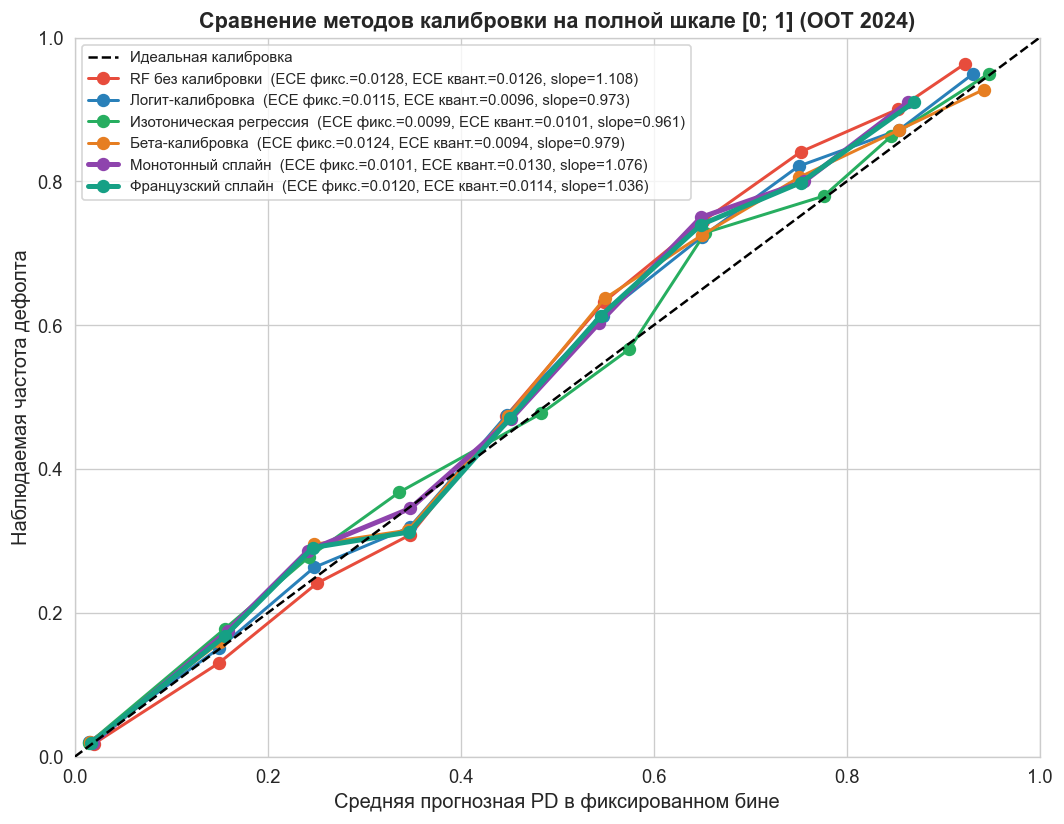

In [29]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Идеальная калибровка", zorder=5)

for (name, probs), color in zip(all_methods.items(), COLORS):
    mean_pred, frac_pos = get_calibration_curve(y_test.values, probs, n_bins=10, strategy="uniform")
    m = summary_metrics(y_test.values, probs)
    lw = 3.0 if "сплайн" in name.lower() else 1.8
    label = f"{name}  (ECE фикс.={m['ece_uniform']:.4f}, ECE квант.={m['ece_quantile']:.4f}, slope={m['cal_slope']:.3f})"
    ax.plot(mean_pred, frac_pos, "o-", color=color, lw=lw, ms=7, label=label)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Средняя прогнозная PD в фиксированном бине", fontsize=12)
ax.set_ylabel("Наблюдаемая частота дефолта", fontsize=12)
ax.set_title("Сравнение методов калибровки на полной шкале [0; 1] (OOT 2024)", fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### Вогнутая функция совокупного капитала под кредитный риск

В данном блоке для каждого метода калибровки строится зависимость между вероятностью дефолта `PD` и отношением капитала к `EAD`. Совокупный капитал разбивается на две части:

- `K_EL = EL / EAD` — ожидаемые потери как доля от экспозиции;
- `K_UL = UL capital / EAD` — капитал под неожиданные потери как доля от экспозиции.

Суммарная кривая `K_EL + K_UL` показывает, как изменение PD влияет на резервирование и капитальную нагрузку. Отдельные графики строятся по каждому методу калибровки, а общий график позволяет сопоставить итоговую капитальную кривую между методами.

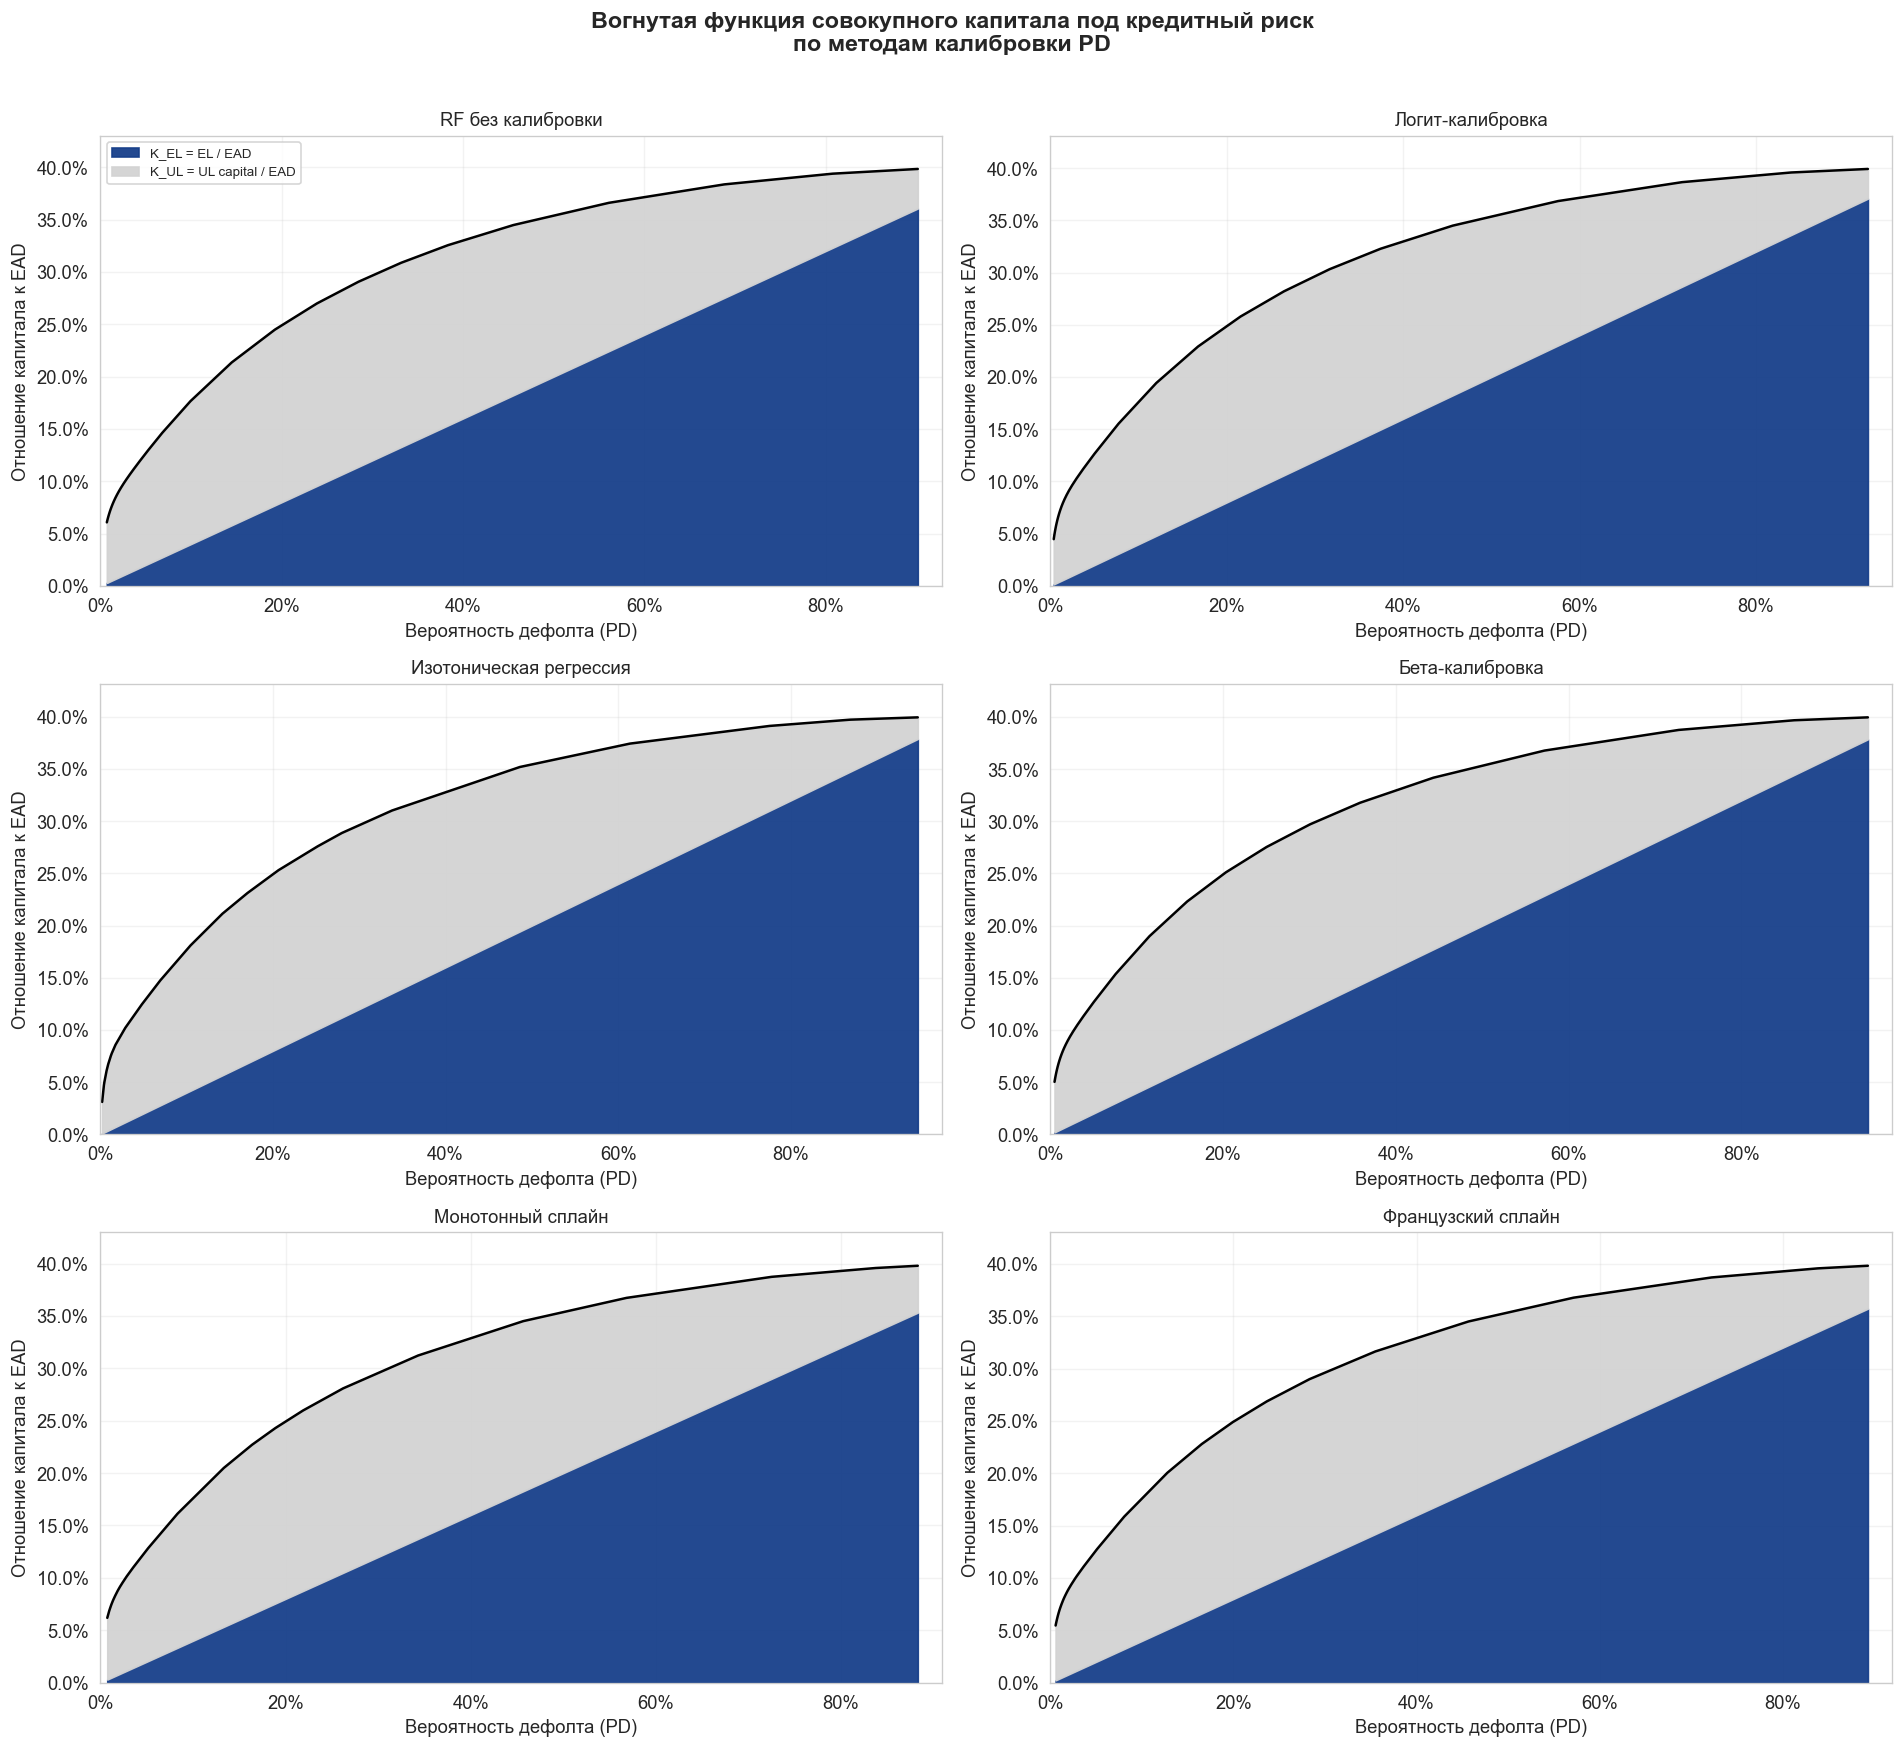

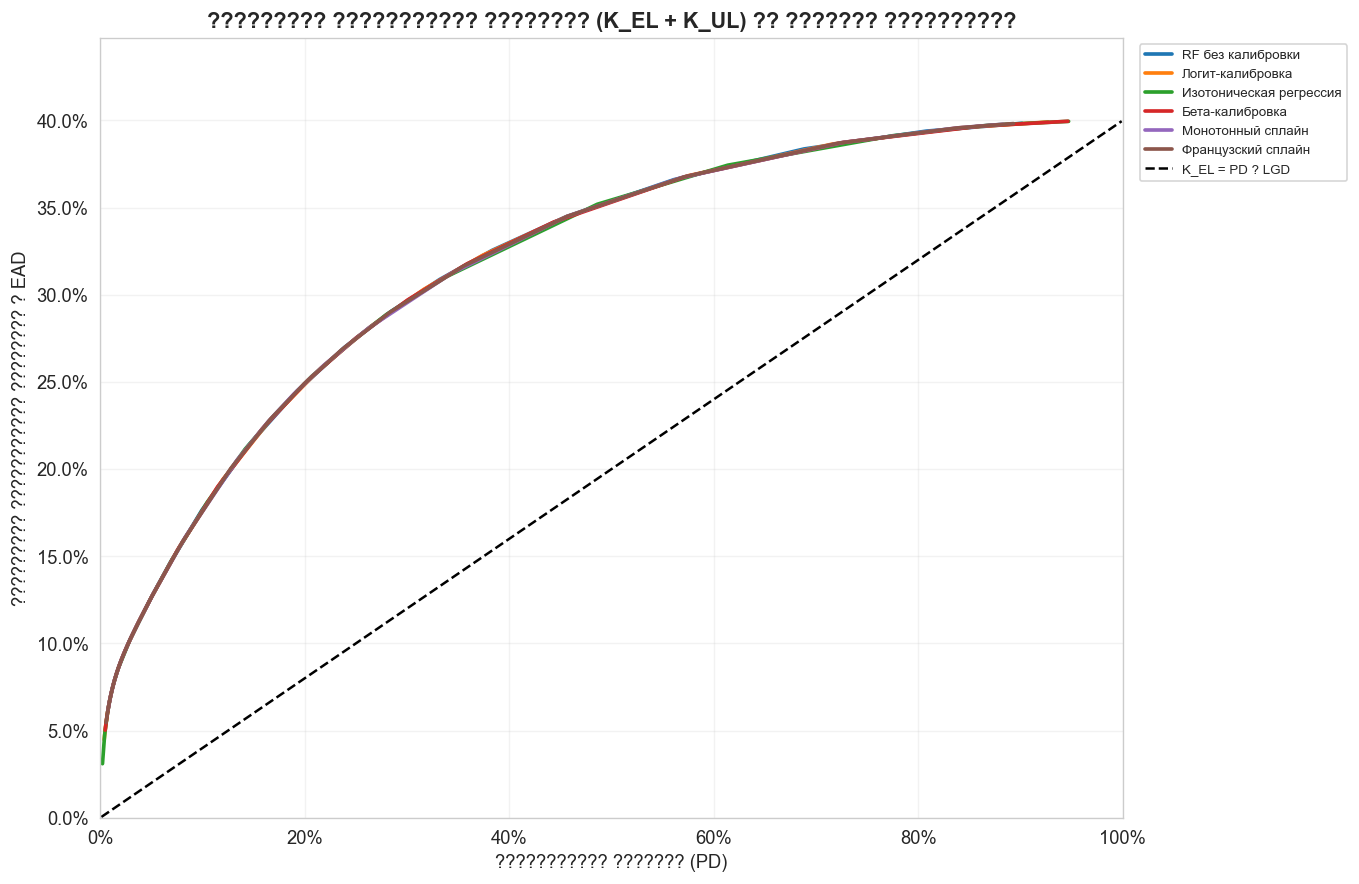

,avg_pd,avg_k_el_ratio,avg_k_ul_ratio,avg_k_total_ratio,max_pd
method,,,,,
RF без калибровки,14.06%,5.62%,9.49%,15.11%,96.60%
Логит-калибровка,13.47%,5.39%,8.42%,13.81%,97.88%
Изотоническая регрессия,13.43%,5.37%,8.48%,13.85%,100.00%
Бета-калибровка,13.46%,5.38%,8.62%,14.00%,98.87%
Монотонный сплайн,13.38%,5.35%,9.39%,14.74%,88.44%
Французский сплайн,13.36%,5.34%,9.01%,14.35%,89.49%


In [30]:
# =========================
# Вогнутая функция совокупного капитала под кредитный риск
# Для каждого метода калибровки + общий график
# =========================

capital_curve_methods = {
    "RF без калибровки": scores_test,
    **calibrated_probs,
}

def build_capital_curve(pd_values, assumptions, n_bins=40):
    """
    Строит сглаженную эмпирическую кривую:
    PD -> K_EL/EAD, K_UL/EAD, K_total/EAD
    
    n_bins: число квантильных бинов для сглаживания.
    """
    pd_values = np.clip(np.asarray(pd_values, dtype=float), 1e-6, 1 - 1e-6)
    pd_values = np.sort(pd_values)

    tmp = calculate_irb_capital(pd_values, assumptions=assumptions).copy()
    tmp["k_el_ratio"] = tmp["expected_loss"] / tmp["ead"]
    tmp["k_ul_ratio"] = tmp["unexpected_loss_capital"] / tmp["ead"]
    tmp["k_total_ratio"] = tmp["k_el_ratio"] + tmp["k_ul_ratio"]

    # Сглаживание через квантильные бины
    if n_bins is not None and len(tmp) > n_bins:
        tmp["pd_bin"] = pd.qcut(tmp["pd"], q=n_bins, duplicates="drop")
        curve = (
            tmp.groupby("pd_bin", observed=True)
            .agg(
                pd=("pd", "mean"),
                k_el_ratio=("k_el_ratio", "mean"),
                k_ul_ratio=("k_ul_ratio", "mean"),
                k_total_ratio=("k_total_ratio", "mean"),
                n=("pd", "size"),
            )
            .reset_index(drop=True)
            .sort_values("pd")
        )
    else:
        curve = tmp[["pd", "k_el_ratio", "k_ul_ratio", "k_total_ratio"]].copy()

    return curve


# -------------------------
# 1. Индивидуальные графики для каждого метода
# -------------------------
n_methods = len(capital_curve_methods)
ncols = 2
nrows = int(np.ceil(n_methods / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (method, probs) in enumerate(capital_curve_methods.items()):
    ax = axes[i]
    curve = build_capital_curve(probs, capital_assumptions, n_bins=40)

    # Нижняя часть: K_EL
    ax.fill_between(
        curve["pd"],
        0,
        curve["k_el_ratio"],
        color="#173f8a",
        alpha=0.95,
        label="K_EL = EL / EAD",
    )

    # Верхняя часть: K_UL
    ax.fill_between(
        curve["pd"],
        curve["k_el_ratio"],
        curve["k_total_ratio"],
        color="lightgray",
        alpha=0.95,
        label="K_UL = UL capital / EAD",
    )

    # Граница суммарного капитала
    ax.plot(
        curve["pd"],
        curve["k_total_ratio"],
        color="black",
        linewidth=1.5,
    )

    ax.set_title(method, fontsize=11)
    ax.set_xlabel("Вероятность дефолта (PD)")
    ax.set_ylabel("Отношение капитала к EAD")
    ax.set_xlim(0, min(1.0, curve["pd"].max() * 1.03))
    ax.set_ylim(0, max(0.35, curve["k_total_ratio"].max() * 1.08))
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(True, alpha=0.25)

    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

# убрать пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Вогнутая функция совокупного капитала под кредитный риск\n"
    "по методам калибровки PD",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()


# -------------------------
# 2. ????? ??????: ????????? ????????? ?????? ????????
# -------------------------
capital_curves = {
    method: build_capital_curve(probs, capital_assumptions, n_bins=40)
    for method, probs in capital_curve_methods.items()
}

max_curve_pd = max(float(curve["pd"].max()) for curve in capital_curves.values())
max_curve_capital = max(float(curve["k_total_ratio"].max()) for curve in capital_curves.values())

pd_grid = np.linspace(0.001, max(0.999, max_curve_pd), 300)
k_el_grid = pd_grid * capital_assumptions.lgd
max_reference_capital = float(k_el_grid.max())

fig, ax = plt.subplots(figsize=(14, 7.5))

for method, curve in capital_curves.items():
    ax.plot(
        curve["pd"],
        curve["k_total_ratio"],
        linewidth=2.2,
        label=method,
    )

# ??? ?????????: ????????? ?????? ??? UL capital.
ax.plot(
    pd_grid,
    k_el_grid,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="K_EL = PD ? LGD",
)

ax.set_title(
    "????????? ??????????? ???????? (K_EL + K_UL) ?? ??????? ??????????",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("??????????? ??????? (PD)")
ax.set_ylabel("????????? ??????????? ???????? ? EAD")
ax.set_xlim(0, min(1.0, max_curve_pd * 1.08))
ax.set_ylim(0, max(max_curve_capital, max_reference_capital) * 1.12)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


# -------------------------
# 3. Таблица-резюме по среднему уровню капитала
# -------------------------
capital_curve_summary = []

for method, probs in capital_curve_methods.items():
    tmp = calculate_irb_capital(probs, assumptions=capital_assumptions).copy()

    capital_curve_summary.append({
        "method": method,
        "avg_pd": np.mean(tmp["pd"]),
        "avg_k_el_ratio": np.mean(tmp["expected_loss"] / tmp["ead"]),
        "avg_k_ul_ratio": np.mean(tmp["unexpected_loss_capital"] / tmp["ead"]),
        "avg_k_total_ratio": np.mean(
            (tmp["expected_loss"] + tmp["unexpected_loss_capital"]) / tmp["ead"]
        ),
        "max_pd": np.max(tmp["pd"]),
    })

capital_curve_summary = pd.DataFrame(capital_curve_summary).set_index("method")

display(
    capital_curve_summary.style.format({
        "avg_pd": "{:.2%}",
        "avg_k_el_ratio": "{:.2%}",
        "avg_k_ul_ratio": "{:.2%}",
        "avg_k_total_ratio": "{:.2%}",
        "max_pd": "{:.2%}",
    })
)

## 8. Выводы, практическая интерпретация и ограничения

In [31]:
print("=" * 90)
print("ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD")
print("=" * 90)

# =========================
# 1. Компактная таблица статистических метрик
# =========================

metric_cols = [
    "brier_score",
    "log_loss",
    "ece_uniform",
    "ece_quantile",
    "hl_p_value",
    "cal_slope",
    "cal_intercept",
]

df_metrics_final = (
    df_results[metric_cols]
    .sort_values(["brier_score", "log_loss", "ece_quantile"])
    .copy()
)

display(
    df_metrics_final.style.format({
        "brier_score": "{:.5f}",
        "log_loss": "{:.5f}",
        "ece_uniform": "{:.5f}",
        "ece_quantile": "{:.5f}",
        "hl_p_value": "{:.3f}",
        "cal_slope": "{:.3f}",
        "cal_intercept": "{:.3f}",
    })
)


# =========================
# 2. Компактная таблица backtesting expected defaults
# =========================

if "method_summary" in globals():
    df_backtest_final = method_summary[[
        "avg_pd",
        "defaults",
        "expected_defaults",
        "default_gap",
        "calibration_ratio",
    ]].copy()

    df_backtest_final["abs_default_gap"] = df_backtest_final["default_gap"].abs()

    display(
        df_backtest_final
        .sort_values("abs_default_gap")
        .style.format({
            "avg_pd": "{:.2%}",
            "defaults": "{:.0f}",
            "expected_defaults": "{:.2f}",
            "default_gap": "{:.2f}",
            "calibration_ratio": "{:.2f}",
            "abs_default_gap": "{:.2f}",
        })
    )


# =========================
# 3. Компактная таблица capital impact
# =========================

h1_col = (
    "h1_0_if_keep_rf_capital"
    if "h1_0_if_keep_rf_capital" in df_rwa.columns
    else "h1_if_keep_raw_capital"
)

df_capital_final = df_rwa[[
    "avg_pd",
    "total_expected_loss",
    "total_rwa",
    "total_required_capital",
    "rwa_saving_vs_baseline_pct",
    h1_col,
]].copy()

df_capital_final["total_expected_loss"] = df_capital_final["total_expected_loss"] / 1_000_000_000
df_capital_final["total_rwa"] = df_capital_final["total_rwa"] / 1_000_000_000
df_capital_final["total_required_capital"] = df_capital_final["total_required_capital"] / 1_000_000_000

df_capital_final = df_capital_final.rename(columns={
    "avg_pd": "Средняя PD",
    "total_expected_loss": "EL / Reserves, млрд",
    "total_rwa": "RWA, млрд",
    "total_required_capital": "Требуемый капитал, млрд",
    "rwa_saving_vs_baseline_pct": "Снижение RWA vs RF",
    h1_col: "Н1.0 при капитале RF",
})

display(
    df_capital_final
    .sort_values("RWA, млрд")
    .style.format({
        "Средняя PD": "{:.2%}",
        "EL / Reserves, млрд": "{:.3f}",
        "RWA, млрд": "{:.3f}",
        "Требуемый капитал, млрд": "{:.3f}",
        "Снижение RWA vs RF": "{:.2%}",
        "Н1.0 при капитале RF": "{:.2%}",
    })
)


# =========================
# 4. Автоматическое определение лучших методов по критериям
# =========================

best_brier = df_results["brier_score"].idxmin()
best_logloss = df_results["log_loss"].idxmin()
best_ece = df_results["ece_quantile"].idxmin()
best_rwa = df_rwa["total_rwa"].idxmin()
best_capital = df_rwa["total_required_capital"].idxmin()

if "method_summary" in globals():
    best_backtest = method_summary["default_gap"].abs().idxmin()
else:
    best_backtest = "не рассчитано"

summary_table = pd.DataFrame([
    {
        "Критерий": "Минимальный Brier Score",
        "Лучший метод": best_brier,
        "Значение": f"{df_results.loc[best_brier, 'brier_score']:.5f}",
        "Интерпретация": "Лучшее среднее качество вероятностного прогноза.",
    },
    {
        "Критерий": "Минимальный Log-Loss",
        "Лучший метод": best_logloss,
        "Значение": f"{df_results.loc[best_logloss, 'log_loss']:.5f}",
        "Интерпретация": "Наиболее сильный результат с учетом штрафа за уверенные ошибки.",
    },
    {
        "Критерий": "Минимальный ECE на квантильных бинах",
        "Лучший метод": best_ece,
        "Значение": f"{df_results.loc[best_ece, 'ece_quantile']:.5f}",
        "Интерпретация": "Лучшее совпадение прогнозных PD с фактическими дефолтами по группам риска.",
    },
    {
        "Критерий": "Минимальная ошибка expected defaults",
        "Лучший метод": best_backtest,
        "Значение": (
            f"{method_summary.loc[best_backtest, 'default_gap']:.2f}"
            if "method_summary" in globals()
            else "—"
        ),
        "Интерпретация": "Лучшее совпадение с фактическим числом дефолтов на OOT.",
    },
    {
        "Критерий": "Минимальный RWA",
        "Лучший метод": best_rwa,
        "Значение": f"{df_rwa.loc[best_rwa, 'total_rwa'] / 1_000_000_000:.3f} млрд",
        "Интерпретация": "Наименьшая капитальная нагрузка по IRB-style расчету.",
    },
    {
        "Критерий": "Минимальный требуемый капитал",
        "Лучший метод": best_capital,
        "Значение": f"{df_rwa.loc[best_capital, 'total_required_capital'] / 1_000_000_000:.3f} млрд",
        "Интерпретация": "Минимальный капитал при нормативе Н1.0 = 8%.",
    },
])

display(summary_table)


# =========================
# 5. Итоговый текстовый вывод
# =========================

print("\n" + "=" * 90)
print("ИТОГОВЫЙ ВЫВОД")
print("=" * 90)

print(
    "1. Единого лучшего метода калибровки нет: разные методы выигрывают по разным критериям. "
    "Поэтому выбор метода нельзя делать только по одной метрике."
)

print(
    f"2. По статистическим метрикам лучшие результаты дают: "
    f"Brier Score — {best_brier}, Log-Loss — {best_logloss}, ECE — {best_ece}."
)

if "method_summary" in globals():
    print(
        f"3. По агрегированному backtesting expected defaults лучший результат показывает: {best_backtest}. "
        "Это важно, потому что метод с хорошими Brier / Log-Loss не обязательно лучше попадает "
        "в фактическое число дефолтов портфеля."
    )

print(
    f"4. Минимальный RWA дает: {best_rwa}; минимальный требуемый капитал дает: {best_capital}. "
    "Однако снижение капитала нельзя трактовать как автоматическое улучшение модели, "
    "если одновременно ухудшается совпадение с фактическими дефолтами."
)

print(
    "5. Метрики ранжирования AUC / Gini / KS почти не меняются после калибровки, "
    "поскольку калибраторы в основном сохраняют порядок заемщиков и меняют именно уровень PD."
)

print(
    f"6. Rating Master Scale A1...E является отдельным уровнем анализа: все методы приводятся "
    f"к целевой CT calibration-периода ({TARGET_CT:.2%}), поэтому в этом блоке сравнивается "
    "не общий уровень expected defaults, а форма рейтинговой PD-кривой."
)

print(
    "7. Для итоговой интерпретации наиболее корректно сопоставлять сразу три блока: "
    "статистические метрики PD, backtesting expected defaults и влияние на RWA / Н1.0."
)

ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ КАЛИБРОВКИ PD


,brier_score,log_loss,ece_uniform,ece_quantile,hl_p_value,cal_slope,cal_intercept
method,,,,,,,
Изотоническая регрессия,0.06094,0.20955,0.00994,0.01015,0.002,0.961,0.119
Бета-калибровка,0.06103,0.20837,0.01236,0.00938,0.013,0.979,0.131
Логит-калибровка,0.06105,0.20884,0.01152,0.00963,0.000,0.973,0.125
Французский сплайн,0.06114,0.20870,0.01203,0.01142,0.014,1.036,0.204
Монотонный сплайн,0.06126,0.20920,0.01006,0.01298,0.008,1.076,0.246
RF без калибровки,0.06134,0.20908,0.01279,0.01258,0.002,1.108,0.152


,avg_pd,defaults,expected_defaults,default_gap,calibration_ratio,abs_default_gap
method,,,,,,
RF без калибровки,14.06%,916,895.84,20.16,1.02,20.16
Логит-калибровка,13.47%,916,858.14,57.86,1.07,57.86
Бета-калибровка,13.46%,916,857.73,58.27,1.07,58.27
Изотоническая регрессия,13.43%,916,855.81,60.19,1.07,60.19
Монотонный сплайн,13.38%,916,852.58,63.42,1.07,63.42
Французский сплайн,13.36%,916,851.41,64.59,1.08,64.59


,Средняя PD,"EL / Reserves, млрд","RWA, млрд","Требуемый капитал, млрд",Снижение RWA vs RF,Н1.0 при капитале RF
method,,,,,,
Логит-калибровка,13.47%,0.343,6.708,0.537,11.21%,9.01%
Изотоническая регрессия,13.43%,0.342,6.754,0.540,10.61%,8.95%
Бета-калибровка,13.46%,0.343,6.866,0.549,9.12%,8.80%
Французский сплайн,13.36%,0.341,7.174,0.574,5.04%,8.42%
Монотонный сплайн,13.38%,0.341,7.476,0.598,1.05%,8.08%
RF без калибровки,14.06%,0.358,7.555,0.604,0.00%,8.00%


,Критерий,Лучший метод,Значение,Интерпретация
0,Минимальный Brier Score,Изотоническая регрессия,0.06094,Лучшее среднее качество вероятностного прогноза.
1,Минимальный Log-Loss,Бета-калибровка,0.20837,Наиболее сильный результат с учетом штрафа за ...
2,Минимальный ECE на квантильных бинах,Бета-калибровка,0.00938,Лучшее совпадение прогнозных PD с фактическими...
3,Минимальная ошибка expected defaults,RF без калибровки,20.16,Лучшее совпадение с фактическим числом дефолто...
4,Минимальный RWA,Логит-калибровка,6.708 млрд,Наименьшая капитальная нагрузка по IRB-style р...
5,Минимальный требуемый капитал,Логит-калибровка,0.537 млрд,Минимальный капитал при нормативе Н1.0 = 8%.



ИТОГОВЫЙ ВЫВОД
1. Единого лучшего метода калибровки нет: разные методы выигрывают по разным критериям. Поэтому выбор метода нельзя делать только по одной метрике.
2. По статистическим метрикам лучшие результаты дают: Brier Score — Изотоническая регрессия, Log-Loss — Бета-калибровка, ECE — Бета-калибровка.
3. По агрегированному backtesting expected defaults лучший результат показывает: RF без калибровки. Это важно, потому что метод с хорошими Brier / Log-Loss не обязательно лучше попадает в фактическое число дефолтов портфеля.
4. Минимальный RWA дает: Логит-калибровка; минимальный требуемый капитал дает: Логит-калибровка. Однако снижение капитала нельзя трактовать как автоматическое улучшение модели, если одновременно ухудшается совпадение с фактическими дефолтами.
5. Метрики ранжирования AUC / Gini / KS почти не меняются после калибровки, поскольку калибраторы в основном сохраняют порядок заемщиков и меняют именно уровень PD.
6. Rating Master Scale A1...E является отдельным уровнем ан